# AI-Driven OSINT Threat Monitoring and Risk Assessment  Prototype

**Technical Assessment Prototype** &nbsp;|&nbsp; *KTP Associate*

---

This notebook is a **working, end-to-end prototype** of an AI-assisted system that turns raw
open-source intelligence (OSINT) and threat-intelligence feeds into a **ranked, actionable
risk register**. It is written as a linear, teaching-style narrative: every stage of the
pipeline produces visible output, so the logic can be inspected and defended step by step
rather than hidden inside modules.

The whole system is a single pipeline:

> **collect → filter → enrich → cluster → score → rank → report**

| Stage | What it does | Notebook section |
|-------|--------------|------------------|
| **Collect** | Pull live threat-intel (CISA KEV) and OSINT news (RSS) | §4 |
| **Filter** | Separate genuine cyber signal from noise (ML classifier vs keyword baseline) | §6 |
| **Enrich** | Extract IOCs, join to KEV, attach severity (CVSS) and exploit-probability (EPSS) | §7 |
| **Map** | Align each item to a MITRE ATT&CK technique | §8 |
| **Cluster** | De-duplicate items describing the same vulnerability and count corroborating sources | §9 |
| **Score** | Apply a transparent 5-factor weighted risk formula | §10 |
| **Rank & report** | Produce the prioritised register, visuals and a "threat report" | §11-12 |

> **Reproducibility note.** In Google Colab (which has internet) the notebook fetches **live**
> data, so your exact numbers will differ from run to run  that is expected and desirable for a
> live monitoring system. For a **deterministic demo** that runs identically every time (and
> offline), set `USE_LIVE_DATA = False` in §3; the notebook then uses a bundled, factually-grounded
> snapshot of real CVEs and real ATT&CK techniques. All outputs shown in this file were produced
> from that fixed snapshot.

## 1. Problem statement and motivation

Security teams do not suffer from a *lack* of information  they drown in it. Two structural
facts make manual triage untenable:

- **The vulnerability backlog is enormous and growing.** Over **40,000** CVEs were published in
  2024 alone, and the total catalogue now exceeds **240,000** entries (CVE Program, 2024). No team
  can read, let alone act on, all of them.
- **Only a small fraction are actually dangerous.** Empirically, **2-5%** of disclosed CVEs are
  ever exploited in the wild (Jacobs et al., 2021, *EPSS*). The hard problem is not *finding*
  vulnerabilities  it is **separating the few that matter from the overwhelming majority that do
  not**, fast enough to act before an adversary does.

At the same time, the *earliest* signal of an active campaign frequently appears in **open
sources**  vendor advisories, security-news reporting and researcher disclosures  often **days
before** an organisation's internal tooling flags anything. The CISA Known Exploited
Vulnerabilities (KEV) catalogue exists precisely because "is this being exploited *right now*?"
is the single most decision-relevant question, and the answer lives in the open.

**This prototype operationalises that insight.** It fuses an authoritative *exploitation* signal
(CISA KEV) with *open-source narrative* signal (news/OSINT), filters out noise with a trained
classifier, enriches each item with indicators and severity, corroborates it across independent
sources, and finally **scores and ranks** every threat so an analyst's attention goes to the
handful of items that genuinely warrant it.

**Design goals (and how we measure success):**

1. **Precision over recall at the noise filter**  an analyst-facing system that cries wolf is
   ignored; we report classifier precision/recall/F1 against a keyword baseline (§6).
2. **Corroboration as a confidence signal**  a flaw reported by KEV *and* three independent
   outlets is more trustworthy than a single unverified post (§9).
3. **Transparent, defensible scoring**  every risk score decomposes into named, inspectable
   factors with one fully worked example (§10).

## 2. System design and architecture

The prototype implements the architecture below. Boxes are processing stages; the store in the
middle is the unified item schema that every stage reads from and writes to. In this notebook the
store is an in-memory pandas `DataFrame`; §13 discusses the production substitutes (a document
store plus a vector index).

```
            DATA SOURCES                  INGESTION                PROCESSING & ANALYSIS
 ┌───────────────────────────┐     ┌──────────────────┐    ┌──────────────────────────────┐
 │ CISA KEV (JSON, authoritative│   │  Scheduled poll  │    │  (6) Relevance filter         │
 │   exploitation signal)      │──▶ │  + normaliser    │──▶ │      TF-IDF + LogisticReg     │
 │                             │    │  (schema mapping)│    │      (baseline: keyword match)│
 │ Google News / NewsAPI RSS   │──▶ │                  │    │  (7) Enrichment: IOC regex,   │
 │   (OSINT narrative signal)  │    └──────────────────┘    │      KEV join, CVSS + EPSS    │
 │                             │             │              │  (8) MITRE ATT&CK mapping     │
 │ MITRE ATT&CK (technique kb) │─────────────┘              │      (TF-IDF cosine sim)      │
 └───────────────────────────┘                             │  (9) Cluster / de-duplicate   │
                                       ┌───────────────┐    │      + corroboration count    │
                                       │ Unified item  │◀──▶│  (10) 5-factor risk score     │
                                       │ store (DF /    │    └──────────────────────────────┘
                                       │ doc DB + vec) │                   │
                                       └───────────────┘                   ▼
                                                              ┌──────────────────────────────┐
                                                              │  (11) Ranked risk register    │
                                                              │  (12) Threat report + visuals │
                                                              └──────────────────────────────┘
```

**Why these three sources.** They are complementary, not redundant. KEV answers *"is it
exploited?"* with authority but no narrative; news answers *"who, how and how widely?"* but is
noisy and unverified; ATT&CK supplies the *adversary-behaviour vocabulary* that lets us describe
*how* a flaw is abused. Fusing them is the core idea  and the corroboration count (§9) is what
turns three weak signals into one strong, defensible one.

## 3. Environment setup

We install the one library Colab lacks (`feedparser`, for RSS) and import everything else.
Standard scientific libraries (`pandas`, `scikit-learn`, `matplotlib`, `seaborn`) ship with Colab.
Pinning a random seed makes the classifier split and any stochastic step reproducible.

The single switch `USE_LIVE_DATA` controls the collect stage: `True` fetches live feeds (Colab),
`False` uses the bundled snapshot (deterministic / offline).

In [566]:
# feedparser is the only dependency Colab does not ship; everything else is preinstalled.
# The "-q" keeps the install quiet. Safe to re-run.
!pip install -q feedparser 2>/dev/null

import re
import json
import textwrap
import warnings
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report)
from sklearn.metrics.pairwise import cosine_similarity

%matplotlib inline
warnings.filterwarnings("ignore")

# ----- Global configuration -------------------------------------------------
RANDOM_STATE  = 42          # makes every split / shuffle reproducible
USE_LIVE_DATA = False      
np.random.seed(RANDOM_STATE)

# Consistent, readable plot styling reused by every figure (no per-figure repetition).
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "figure.autolayout": True,
    "axes.titleweight": "bold", "axes.titlesize": 12, "font.size": 10,
})
PALETTE = {"Critical": "#C0392B", "High": "#E67E22", "Medium": "#F1C40F", "Low": "#27AE60"}

print("Environment ready.")
print(f"  pandas {pd.__version__} | numpy {np.__version__}")
print(f"  USE_LIVE_DATA = {USE_LIVE_DATA}")

Environment ready.
  pandas 3.0.3 | numpy 2.4.6
  USE_LIVE_DATA = False


The system cannot find the path specified.


### 3.1 Bundled snapshot (reproducible fallback)

The cell below defines the deterministic snapshot used when `USE_LIVE_DATA = False`. It is **real
data, condensed**: the CVEs and their vendor/product/weakness metadata are genuine CISA KEV
entries, and the ATT&CK techniques are genuine framework entries. The two values that CISA KEV
does *not* publish  the **CVSS base score** (severity) and the **EPSS probability** (likelihood
of exploitation)  are bundled here as demo stand-ins; §7 marks clearly where the production
system would fetch these live from the NVD and FIRST APIs. Keeping provenance explicit is
deliberate: an assessor should be able to see exactly which numbers are authoritative and which
are illustrative.

In [567]:
# Bundled, factually-grounded sample of the CISA Known Exploited Vulnerabilities (KEV)
# catalogue. These are REAL CVEs with real vendor/product/weakness metadata.
# cvss_base and epss are bundled demo stand-ins (in production these come live from
# the NVD CVSS API and the FIRST EPSS API respectively).

SAMPLE_KEV = [
 ("CVE-2024-3400","Palo Alto Networks","PAN-OS GlobalProtect","Command Injection Vulnerability","2024-04-12","CWE-77","Unknown",10.0,0.94),
 ("CVE-2021-44228","Apache","Log4j2","Log4Shell Remote Code Execution Vulnerability","2021-12-10","CWE-917","Known",10.0,0.97),
 ("CVE-2023-34362","Progress","MOVEit Transfer","SQL Injection Vulnerability","2023-06-02","CWE-89","Known",9.8,0.95),
 ("CVE-2023-4966","Citrix","NetScaler ADC and Gateway","Sensitive Information Disclosure (CitrixBleed) Vulnerability","2023-10-18","CWE-119","Known",9.4,0.94),
 ("CVE-2024-21887","Ivanti","Connect Secure and Policy Secure","Command Injection Vulnerability","2024-01-10","CWE-77","Unknown",9.1,0.92),
 ("CVE-2023-46805","Ivanti","Connect Secure and Policy Secure","Authentication Bypass Vulnerability","2024-01-10","CWE-287","Unknown",8.2,0.90),
 ("CVE-2022-30190","Microsoft","Windows MSDT","Follina Remote Code Execution Vulnerability","2022-06-14","CWE-610","Known",7.8,0.96),
 ("CVE-2021-34527","Microsoft","Windows Print Spooler","PrintNightmare Remote Code Execution Vulnerability","2021-11-03","CWE-269","Known",8.8,0.94),
 ("CVE-2024-1709","ConnectWise","ScreenConnect","Authentication Bypass Vulnerability","2024-02-22","CWE-288","Known",10.0,0.93),
 ("CVE-2023-20198","Cisco","IOS XE Web UI","Privilege Escalation Vulnerability","2023-10-16","CWE-420","Unknown",10.0,0.95),
 ("CVE-2022-1388","F5","BIG-IP","iControl REST Authentication Bypass Vulnerability","2022-05-18","CWE-306","Unknown",9.8,0.95),
 ("CVE-2021-26855","Microsoft","Exchange Server","ProxyLogon Remote Code Execution Vulnerability","2021-11-03","CWE-918","Known",9.8,0.97),
 ("CVE-2021-34473","Microsoft","Exchange Server","ProxyShell Remote Code Execution Vulnerability","2021-11-03","CWE-918","Known",9.8,0.96),
 ("CVE-2023-27997","Fortinet","FortiOS SSL-VPN","Heap-Based Buffer Overflow Vulnerability","2024-03-18","CWE-787","Unknown",9.8,0.88),
 ("CVE-2022-40684","Fortinet","FortiOS and FortiProxy","Authentication Bypass Vulnerability","2022-10-11","CWE-288","Unknown",9.8,0.94),
 ("CVE-2023-3519","Citrix","NetScaler ADC and Gateway","Code Injection Remote Code Execution Vulnerability","2023-07-20","CWE-94","Unknown",9.8,0.95),
 ("CVE-2020-1472","Microsoft","Netlogon","Zerologon Privilege Escalation Vulnerability","2021-11-03","CWE-330","Known",10.0,0.96),
 ("CVE-2019-19781","Citrix","ADC and Gateway","Directory Traversal Vulnerability","2021-11-03","CWE-22","Known",9.8,0.97),
 ("CVE-2018-13379","Fortinet","FortiOS SSL VPN","Path Traversal Information Disclosure Vulnerability","2021-11-03","CWE-22","Known",9.8,0.97),
 ("CVE-2023-22515","Atlassian","Confluence Data Center and Server","Broken Access Control Privilege Escalation Vulnerability","2023-10-04","CWE-284","Unknown",10.0,0.93),
 ("CVE-2022-26134","Atlassian","Confluence Server and Data Center","OGNL Injection Remote Code Execution Vulnerability","2022-06-03","CWE-917","Known",9.8,0.96),
 ("CVE-2023-42793","JetBrains","TeamCity","Authentication Bypass Remote Code Execution Vulnerability","2023-10-04","CWE-288","Unknown",9.8,0.92),
 ("CVE-2023-2868","Barracuda","Email Security Gateway","Command Injection Vulnerability","2023-05-26","CWE-77","Unknown",9.8,0.90),
 ("CVE-2024-21412","Microsoft","Windows SmartScreen","Internet Shortcut Files Security Feature Bypass Vulnerability","2024-02-13","CWE-693","Unknown",8.1,0.85),
 ("CVE-2024-27198","JetBrains","TeamCity","Authentication Bypass Vulnerability","2024-03-08","CWE-288","Unknown",9.8,0.90),
 ("CVE-2023-36884","Microsoft","Windows Search","Windows Search Remote Code Execution Vulnerability","2023-07-17","CWE-610","Known",8.8,0.88),
 ("CVE-2023-38831","RARLAB","WinRAR","Code Execution Vulnerability","2023-08-24","CWE-345","Unknown",7.8,0.90),
 ("CVE-2022-22965","VMware Tanzu","Spring Framework","Spring4Shell Remote Code Execution Vulnerability","2022-04-04","CWE-94","Unknown",9.8,0.95),
 ("CVE-2021-21972","VMware","vCenter Server","Remote Code Execution Vulnerability","2021-11-03","CWE-22","Unknown",9.8,0.94),
 ("CVE-2023-20273","Cisco","IOS XE Web UI","Command Injection Privilege Escalation Vulnerability","2023-10-23","CWE-77","Unknown",7.2,0.85),
 ("CVE-2024-4040","CrushFTP","CrushFTP","Server-Side Template Injection Vulnerability","2024-04-24","CWE-1336","Unknown",9.8,0.88),
 ("CVE-2024-20353","Cisco","Adaptive Security Appliance and FTD","Denial-of-Service Vulnerability","2024-04-24","CWE-20","Unknown",8.6,0.60),
 ("CVE-2023-48788","Fortinet","FortiClientEMS","SQL Injection Vulnerability","2024-03-21","CWE-89","Unknown",9.8,0.85),
 ("CVE-2022-41040","Microsoft","Exchange Server","ProxyNotShell Server-Side Request Forgery Vulnerability","2022-10-03","CWE-918","Known",8.8,0.93),
 ("CVE-2022-41082","Microsoft","Exchange Server","ProxyNotShell Remote Code Execution Vulnerability","2022-10-03","CWE-918","Known",8.8,0.93),
 ("CVE-2021-40539","Zoho","ManageEngine ADSelfService Plus","Authentication Bypass Remote Code Execution Vulnerability","2021-11-03","CWE-287","Known",9.8,0.94),
 ("CVE-2022-47966","Zoho","ManageEngine Multiple Products","Remote Code Execution Vulnerability","2023-01-23","CWE-611","Unknown",9.8,0.92),
 ("CVE-2023-28252","Microsoft","Windows CLFS Driver","Privilege Escalation Vulnerability","2023-04-11","CWE-787","Known",7.8,0.80),
 ("CVE-2024-21893","Ivanti","Connect Secure and Policy Secure","Server-Side Request Forgery Vulnerability","2024-01-31","CWE-918","Unknown",8.2,0.88),
 ("CVE-2023-7028","GitLab","Community and Enterprise Edition","Account Takeover via Password Reset Vulnerability","2024-05-01","CWE-640","Unknown",10.0,0.70),
]

# Bundled OSINT / news sample mimicking a Google News RSS pull.
# Fields: (title, source, published, summary)
# The mix is deliberate: ~24 cyber-relevant items and ~13 clear "noise" items
# (sport, markets, entertainment, lifestyle) so the relevance filter has something
# real to separate. Several cyber items deliberately reference the SAME CVE across
# different outlets so the de-duplication / corroboration stage has signal.
# A few summaries embed realistic IOCs (IPs, hashes, domains) for the enrichment regex.

SAMPLE_NEWS = [
 # --- PAN-OS CVE-2024-3400: covered by 3 outlets (centrepiece corroboration) ---
 ("Palo Alto Networks warns of critical PAN-OS zero-day under active exploitation","BleepingComputer","2024-04-12",
  "Attackers are exploiting CVE-2024-3400, a command injection flaw in the GlobalProtect feature of PAN-OS firewalls, to deploy a Python backdoor. Observed C2 traffic to 193.34.214.83."),
 ("CISA adds Palo Alto PAN-OS command injection bug to KEV catalog","The Hacker News","2024-04-13",
  "CVE-2024-3400 has been added to the CISA Known Exploited Vulnerabilities catalog. Federal agencies must patch the PAN-OS GlobalProtect vulnerability immediately."),
 ("State-linked actors weaponise Palo Alto firewall flaw to breach networks","SecurityWeek","2024-04-16",
  "Researchers attribute exploitation of the PAN-OS vulnerability CVE-2024-3400 to a sophisticated threat cluster. Payload hash 5b3f0c1d9e7a2b4c6f8e0a1b2c3d4e5f6a7b8c9d0e1f2a3b4c5d6e7f8a9b0c1d."),
 # --- MOVEit CVE-2023-34362: 2 outlets ---
 ("Clop ransomware gang exploits MOVEit Transfer zero-day in mass data theft","BleepingComputer","2023-06-05",
  "The Clop ransomware group is behind mass exploitation of CVE-2023-34362, a SQL injection flaw in Progress MOVEit Transfer, stealing data from hundreds of organisations."),
 ("MOVEit breach victim count climbs past 600 organisations","The Record","2023-07-10",
  "The fallout from the MOVEit Transfer vulnerability CVE-2023-34362 continues to grow, with newly disclosed victims across finance, healthcare and government."),
 # --- CitrixBleed CVE-2023-4966: 2 outlets ---
 ("CitrixBleed: NetScaler flaw exploited to hijack user sessions","SecurityWeek","2023-10-25",
  "CVE-2023-4966, dubbed CitrixBleed, lets attackers steal session tokens from NetScaler ADC and Gateway appliances, bypassing MFA. Exploit traffic seen from 45.142.212.61."),
 ("Ransomware groups pile onto CitrixBleed as exploitation surges","The Hacker News","2023-11-02",
  "Multiple ransomware affiliates are leveraging the Citrix NetScaler vulnerability CVE-2023-4966 for initial access, CISA warns in a joint advisory."),
 # --- Ivanti CVE-2024-21887 / 46805: 2 outlets ---
 ("Ivanti Connect Secure VPN zero-days chained for unauthenticated RCE","The Hacker News","2024-01-11",
  "Two Ivanti vulnerabilities, CVE-2023-46805 and CVE-2024-21887, are being chained by suspected nation-state actors to achieve remote code execution on VPN appliances."),
 ("Thousands of Ivanti VPN appliances remain unpatched as attacks widen","SecurityWeek","2024-01-22",
  "Scanning shows widespread exploitation of the Ivanti Connect Secure flaws. Malicious domain update.ivanti-security[.]help observed serving web shells."),
 # --- General cyber news (no single CVE, still clearly relevant) ---
 ("LockBit ransomware affiliate arrested in international law enforcement operation","The Record","2024-02-20",
  "Operation Cronos disrupted the LockBit ransomware-as-a-service operation, seizing infrastructure and decryption keys after months of coordinated effort."),
 ("Phishing campaign abuses Microsoft 365 to harvest corporate credentials","BleepingComputer","2024-03-04",
  "A large-scale phishing campaign is using adversary-in-the-middle techniques to bypass MFA and steal Microsoft 365 session cookies from enterprise users."),
 ("Healthcare provider discloses data breach affecting 2.3 million patients","The Record","2024-03-19",
  "A US healthcare network confirmed that attackers exfiltrated patient records following an intrusion. The threat actor demanded a ransom to prevent publication."),
 ("Cisco IOS XE web UI implant infects tens of thousands of devices","The Hacker News","2023-10-17",
  "Mass exploitation of CVE-2023-20198 in Cisco IOS XE has led to widespread deployment of a malicious implant granting attackers full device control."),
 ("New malware loader distributed through malicious search engine adverts","SecurityWeek","2024-02-28",
  "A malvertising campaign is delivering a stealthy loader that drops infostealers. The loader beacons to command-and-control server 91.92.250.104 over HTTPS."),
 ("Critical Confluence flaw exploited days after disclosure","BleepingComputer","2023-10-06",
  "Attackers are actively exploiting CVE-2023-22515 in Atlassian Confluence Data Center to create rogue administrator accounts on internet-facing servers."),
 ("Fortinet FortiOS heap overflow exploited in attacks on government targets","The Hacker News","2024-03-20",
  "CVE-2023-27997, a heap-based buffer overflow in FortiOS SSL-VPN, is being used to compromise government and critical infrastructure networks."),
 ("Apache Log4j flaw still exploited two years after Log4Shell disclosure","SecurityWeek","2023-12-11",
  "Despite patches being available since 2021, CVE-2021-44228 (Log4Shell) continues to be one of the most exploited vulnerabilities targeting unpatched Java applications."),
 ("Threat actors abuse WinRAR vulnerability to target traders","The Record","2023-09-01",
  "CVE-2023-38831 in WinRAR is being exploited to deliver malware to cryptocurrency and stock trading forums, researchers report."),
 ("ConnectWise ScreenConnect flaw triggers emergency patching scramble","BleepingComputer","2024-02-23",
  "CVE-2024-1709, a maximum-severity authentication bypass in ConnectWise ScreenConnect, is being mass-exploited to deploy ransomware and remote access tools."),
 ("DDoS attack disrupts European banking services for several hours","SecurityWeek","2024-03-12",
  "A distributed denial-of-service attack briefly took several European banks offline. A pro-hacktivist group claimed responsibility on Telegram."),
 ("Supply-chain attack pushes trojanised updates to enterprise software users","The Hacker News","2024-04-02",
  "Attackers compromised a software vendor's update mechanism to distribute a backdoor, echoing previous high-profile supply-chain incidents."),
 ("Microsoft patches actively exploited Windows SmartScreen bypass","BleepingComputer","2024-02-14",
  "February's Patch Tuesday addresses CVE-2024-21412, a SmartScreen security feature bypass already used in financially motivated attacks."),
 ("Zero-day broker prices for mobile exploits hit record highs","The Record","2024-01-30",
  "The market for zero-day exploits continues to expand, with brokers offering seven-figure sums for full-chain mobile remote code execution."),
 ("GitLab urges immediate patching of account takeover vulnerability","The Hacker News","2024-05-02",
  "CVE-2023-7028 allows attackers to trigger password-reset emails to attacker-controlled addresses, enabling account takeover without interaction."),
 # --- Reported but NOT (yet) in CISA KEV: emerging / unconfirmed CVEs ---
 ("Backdoor discovered in xz Utils threatens Linux supply chain","The Hacker News","2024-03-29",
  "A malicious backdoor tracked as CVE-2024-3094 was planted in the xz Utils compression library, nearly compromising countless Linux distributions before discovery."),
 ("Researchers detail xz Utils supply-chain backdoor and its near miss","SecurityWeek","2024-04-01",
  "Analysis of CVE-2024-3094 reveals a patient, multi-year social-engineering effort to insert a backdoor into widely used open-source code."),
 ("Jenkins arbitrary file read flaw under active scanning","BleepingComputer","2024-01-26",
  "CVE-2024-23897 in the Jenkins automation server allows attackers to read arbitrary files; mass internet scanning for vulnerable servers has begun."),
 # --- NOISE: clearly not cyber-security relevant ---
 ("Champions League semi-final ends in dramatic penalty shootout","BBC Sport","2024-04-30",
  "An extraordinary night of football saw the tie decided on penalties after a 2-2 draw across both legs."),
 ("Stock markets rally as central bank signals interest rate pause","Reuters","2024-03-21",
  "Equities climbed across major indices after policymakers indicated that rate hikes may be coming to an end."),
 ("Award-winning film sweeps the board at this year's ceremony","Variety","2024-03-11",
  "The historical drama took home seven awards including best picture and best director at a star-studded ceremony."),
 ("Scientists discover new species of deep-sea coral off the coast","National Geographic","2024-02-18",
  "Researchers exploring an underwater canyon have catalogued a vibrant new coral species at record depths."),
 ("Five easy weeknight pasta recipes for busy families","Good Food","2024-01-15",
  "From classic carbonara to a quick puttanesca, these recipes get a satisfying dinner on the table in under thirty minutes."),
 ("Heatwave expected to break temperature records across the region","Met Office","2024-06-01",
  "Forecasters warn of an incoming heatwave with temperatures climbing well above seasonal averages this week."),
 ("Tech giant unveils new flagship smartphone with improved camera","The Verge","2024-04-10",
  "The latest handset features a redesigned camera system, a brighter display and a faster processor, the company announced."),
 ("Marathon world record broken at major city event","BBC Sport","2024-04-21",
  "A stunning run saw the course record shattered as elite athletes battled cool conditions and an enthusiastic crowd."),
 ("New art exhibition celebrates a century of modern design","The Guardian","2024-03-29",
  "The retrospective brings together furniture, posters and product design spanning a hundred years of creative innovation."),
 ("Electric vehicle sales surpass expectations in the first quarter","Bloomberg","2024-04-05",
  "Quarterly figures show electric vehicle adoption accelerating faster than analysts had forecast, driven by new budget models."),
 ("Local council approves plans for new community park and cycle paths","Local News","2024-02-26",
  "The development will add green space, a playground and several kilometres of cycle routes to the neighbourhood."),
 ("Chef's new cookbook focuses on seasonal vegetarian cooking","Good Food","2024-05-08",
  "The collection of plant-forward recipes emphasises local, seasonal produce and simple techniques for home cooks."),
 ("Travel guide names top ten destinations for autumn getaways","Conde Nast Traveller","2024-03-02",
  "From mountain retreats to coastal towns, this year's list highlights places to visit as the seasons turn."),
]

# Bundled extract of the MITRE ATT&CK Enterprise framework (techniques).
# Fields: (technique_id, name, description)
# The full STIX bundle is ~50 MB; for a teaching/demo notebook we bundle a focused
# extract of techniques most relevant to initial access, execution, persistence,
# privilege escalation and impact. Descriptions are condensed from the official
# ATT&CK technique descriptions. Every ID below was verified to exist in MITRE
# ATT&CK Enterprise (see the provenance appendix); the non-existent "T1190.001"
# from an earlier draft was removed (T1190 has no sub-techniques).

SAMPLE_ATTACK = [
 ("T1190","Exploit Public-Facing Application","Adversaries exploit a weakness in an Internet-facing host or system to gain initial access to a network. This includes exploiting software vulnerabilities, injection flaws, authentication bypass and server-side request forgery in web applications, VPNs, firewalls and remote services."),
 ("T1133","External Remote Services","Adversaries leverage external-facing remote services such as VPNs, Citrix and other access mechanisms to connect to internal network resources from outside, often using valid accounts."),
 ("T1059","Command and Scripting Interpreter","Adversaries abuse command and script interpreters to execute commands, scripts or binaries. This includes shells, PowerShell, Python and operating system command injection."),
 ("T1505.003","Web Shell","Adversaries install a web shell on a compromised web server to establish persistent access, allowing them to execute commands and maintain a foothold on the system."),
 ("T1078","Valid Accounts","Adversaries obtain and abuse credentials of existing accounts to gain initial access, persistence, privilege escalation or defense evasion, blending in with legitimate activity."),
 ("T1068","Exploitation for Privilege Escalation","Adversaries exploit software vulnerabilities to elevate privileges, taking advantage of programming errors in a program, service, kernel or driver to execute code with higher permissions."),
 ("T1210","Exploitation of Remote Services","Adversaries exploit a vulnerability in a remote service to gain unauthorised access to internal systems once inside a network, enabling lateral movement."),
 ("T1486","Data Encrypted for Impact","Adversaries encrypt data on target systems to interrupt availability, demanding a ransom payment for decryption. This is the hallmark of ransomware operations."),
 ("T1566","Phishing","Adversaries send phishing messages to gain access to victim systems, using malicious attachments or links to harvest credentials or deliver malware."),
 ("T1566.002","Spearphishing Link","Adversaries send targeted emails containing malicious links that direct the victim to credential-harvesting pages or malware downloads."),
 ("T1071","Application Layer Protocol","Adversaries communicate using application layer protocols such as HTTP or HTTPS to blend command-and-control traffic with normal network activity and avoid detection."),
 ("T1071.001","Web Protocols","Adversaries use web protocols such as HTTP and HTTPS for command-and-control, embedding commands within traffic that mimics legitimate web browsing."),
 ("T1110","Brute Force","Adversaries use brute force techniques to gain access to accounts when passwords are unknown or when password hashes are obtained, including password spraying."),
 ("T1203","Exploitation for Client Execution","Adversaries exploit software vulnerabilities in client applications such as browsers, office documents and archive utilities to execute code when a user opens a file."),
 ("T1136","Create Account","Adversaries create an account to maintain access to victim systems, including local, domain or cloud accounts with sufficient privileges."),
 ("T1556","Modify Authentication Process","Adversaries modify authentication mechanisms to bypass multi-factor authentication, steal session tokens or maintain access to accounts."),
 ("T1539","Steal Web Session Cookie","Adversaries steal web application or service session cookies to authenticate to a service as the user, bypassing multi-factor authentication controls."),
 ("T1499","Endpoint Denial of Service","Adversaries perform denial-of-service attacks to degrade or block the availability of services to users by exhausting the resources of the targeted system."),
 ("T1498","Network Denial of Service","Adversaries perform distributed denial-of-service attacks to degrade or block the availability of targeted resources by saturating network bandwidth."),
 ("T1195","Supply Chain Compromise","Adversaries manipulate products or delivery mechanisms before they reach the consumer, including compromising software update channels to distribute malicious code."),
 ("T1195.002","Compromise Software Supply Chain","Adversaries manipulate application software prior to receipt by a consumer, inserting backdoors into legitimate software distributed through trusted channels."),
 ("T1572","Protocol Tunneling","Adversaries tunnel network communications to and from a system over an otherwise unrelated protocol to bypass network filtering and conceal traffic."),
 ("T1090","Proxy","Adversaries use a connection proxy to direct network traffic between systems or to act as an intermediary for network communications and evade detection."),
 ("T1003","OS Credential Dumping","Adversaries dump credentials from the operating system and software to obtain account login and credential material, typically in the form of hashes or plaintext passwords."),
 ("T1112","Modify Registry","Adversaries interact with the Windows registry to hide configuration information, store malicious payloads, or enable persistence and execution."),
 ("T1547","Boot or Logon Autostart Execution","Adversaries configure system settings to automatically execute a program during system boot or logon to maintain persistence on compromised systems."),
 ("T1018","Remote System Discovery","Adversaries attempt to get a listing of other systems by IP address, hostname or other identifier on a network for subsequent lateral movement."),
 ("T1041","Exfiltration Over C2 Channel","Adversaries steal data by exfiltrating it over an existing command-and-control channel, encoding the stolen data within normal communications."),
 ("T1567","Exfiltration Over Web Service","Adversaries use legitimate external web services to exfiltrate data, blending exfiltration traffic with normal usage of cloud and web platforms."),
 ("T1219","Remote Access Tools","Adversaries use legitimate remote access tools such as remote monitoring and management software to establish interactive command-and-control channels."),
 ("T1505","Server Software Component","Adversaries abuse legitimate extensible server features to establish persistent access to systems, including web shells and malicious modules."),
 ("T1212","Exploitation for Credential Access","Adversaries exploit software vulnerabilities to collect credentials, taking advantage of flaws that expose authentication material."),
 ("T1574","Hijack Execution Flow","Adversaries hijack the way operating systems run programs to execute their own malicious payloads, for example through library or path manipulation."),
 ("T1027","Obfuscated Files or Information","Adversaries make an executable or file difficult to discover or analyse by encrypting, encoding or otherwise obfuscating its contents."),
]

print(f'Bundled snapshot loaded: {len(SAMPLE_KEV)} KEV entries, {len(SAMPLE_NEWS)} news items, {len(SAMPLE_ATTACK)} ATT&CK techniques.')

Bundled snapshot loaded: 40 KEV entries, 40 news items, 34 ATT&CK techniques.


## 4. Collect  data acquisition

Each source has its own small loader that **tries the live feed and falls back to the snapshot**.
This single pattern (attempt → normalise → fall back) keeps the notebook runnable anywhere while
behaving as a true live monitor in Colab. Every loader returns a tidy `DataFrame` with a fixed
schema, so all downstream stages are source-agnostic.

### 4.1 Threat intelligence  CISA Known Exploited Vulnerabilities (KEV)

The KEV catalogue is the authoritative answer to *"is this being exploited in the wild?"*. It is a
single JSON document, so ingestion is trivial  the engineering value is in **normalising** it to
our schema and parsing dates so we can reason about recency later.

In [568]:
KEV_URL = "https://www.cisa.gov/sites/default/files/feeds/known_exploited_vulnerabilities.json"

def load_kev(use_live: bool) -> pd.DataFrame:
    """Return the KEV catalogue as a normalised DataFrame (live feed or snapshot)."""
    rows = None
    if use_live:
        try:
            import urllib.request
            req = urllib.request.Request(KEV_URL, headers={"User-Agent": "osint-prototype/1.0"})
            raw = json.loads(urllib.request.urlopen(req, timeout=30).read())
            rows = [(v["cveID"], v["vendorProject"], v["product"], v["vulnerabilityName"],
                     v["dateAdded"], (v.get("cwes") or ["N/A"])[0],
                     v.get("knownRansomwareCampaignUse", "Unknown"), np.nan, np.nan)
                    for v in raw["vulnerabilities"]]
            print(f"Fetched {len(rows):,} live KEV entries from CISA.")
        except Exception as e:                       # network blocked / offline -> snapshot
            print(f"Live fetch failed ({type(e).__name__}); using bundled snapshot.")
    if rows is None:
        rows = SAMPLE_KEV
        print(f"Using bundled snapshot: {len(rows)} KEV entries.")
    cols = ["cve", "vendor", "product", "vuln_name", "date_added",
            "cwe", "ransomware", "cvss_base", "epss"]
    df = pd.DataFrame(rows, columns=cols)
    df["date_added"] = pd.to_datetime(df["date_added"])
    return df

df_kev = load_kev(USE_LIVE_DATA)
print(f"\nKEV schema: {list(df_kev.columns)}")
df_kev.head()

Using bundled snapshot: 40 KEV entries.

KEV schema: ['cve', 'vendor', 'product', 'vuln_name', 'date_added', 'cwe', 'ransomware', 'cvss_base', 'epss']


,cve,vendor,product,vuln_name,date_added,cwe,ransomware,cvss_base,epss
0,CVE-2024-3400,Palo Alto Networks,PAN-OS GlobalProtect,Command Injection Vulnerability,2024-04-12,CWE-77,Unknown,10.0,0.94
1,CVE-2021-44228,Apache,Log4j2,Log4Shell Remote Code Execution Vulnerability,2021-12-10,CWE-917,Known,10.0,0.97
2,CVE-2023-34362,Progress,MOVEit Transfer,SQL Injection Vulnerability,2023-06-02,CWE-89,Known,9.8,0.95
3,CVE-2023-4966,Citrix,NetScaler ADC and Gateway,Sensitive Information Disclosure (CitrixBleed)...,2023-10-18,CWE-119,Known,9.4,0.94
4,CVE-2024-21887,Ivanti,Connect Secure and Policy Secure,Command Injection Vulnerability,2024-01-10,CWE-77,Unknown,9.1,0.92


### 4.2 OSINT  security news via RSS

News is the *narrative* layer: it tells us which flaws are being discussed, by whom, and how
widely. It is also where the noise lives  the same feed returns sport, markets and lifestyle
stories, which is exactly why the relevance filter in §6 is necessary. In Colab we pull Google
News RSS with `feedparser`; offline we use the snapshot.

In [569]:
NEWS_QUERY = "cyber attack OR ransomware OR vulnerability OR data breach"

def load_news(use_live: bool) -> pd.DataFrame:
    """Return security-news items as a normalised DataFrame (RSS or snapshot)."""
    rows = None
    if use_live:
        try:
            import feedparser, urllib.parse
            url = "https://news.google.com/rss/search?q=" + urllib.parse.quote(NEWS_QUERY)
            feed = feedparser.parse(url)
            rows = [(e.get("title", ""), e.get("source", {}).get("title", "Google News"),
                     e.get("published", ""), re.sub("<[^>]+>", "", e.get("summary", "")))
                    for e in feed.entries]
            print(f"Fetched {len(rows)} live news items.")
        except Exception as e:
            print(f"Live fetch failed ({type(e).__name__}); using bundled snapshot.")
    if rows is None:
        rows = SAMPLE_NEWS
        print(f"Using bundled snapshot: {len(rows)} news items.")
    df = pd.DataFrame(rows, columns=["title", "source", "published", "summary"])
    df["published"] = pd.to_datetime(df["published"], errors="coerce")
    df["text"] = (df["title"] + ". " + df["summary"]).str.strip()
    return df

df_news = load_news(USE_LIVE_DATA)
print(f"\nNews schema: {list(df_news.columns)}")
df_news[["title", "source", "published"]].head()

Using bundled snapshot: 40 news items.

News schema: ['title', 'source', 'published', 'summary', 'text']


,title,source,published
0,Palo Alto Networks warns of critical PAN-OS ze...,BleepingComputer,2024-04-12
1,CISA adds Palo Alto PAN-OS command injection b...,The Hacker News,2024-04-13
2,State-linked actors weaponise Palo Alto firewa...,SecurityWeek,2024-04-16
3,Clop ransomware gang exploits MOVEit Transfer ...,BleepingComputer,2023-06-05
4,MOVEit breach victim count climbs past 600 org...,The Record,2023-07-10


### 4.3 MITRE ATT&CK technique knowledge base

ATT&CK gives us a controlled vocabulary of adversary behaviours. The full STIX bundle is ~50 MB;
for a teaching prototype we load a focused extract (initial-access, execution, persistence,
privilege-escalation and impact techniques)  enough to demonstrate the mapping in §8 without a
download bottleneck during a live demo.

In [570]:
df_attack = pd.DataFrame(SAMPLE_ATTACK, columns=["technique_id", "technique_name", "description"])
print(f"Loaded {len(df_attack)} ATT&CK techniques.")
df_attack.head()

Loaded 34 ATT&CK techniques.


,technique_id,technique_name,description
0,T1190,Exploit Public-Facing Application,Adversaries exploit a weakness in an Internet-...
1,T1133,External Remote Services,Adversaries leverage external-facing remote se...
2,T1059,Command and Scripting Interpreter,Adversaries abuse command and script interpret...
3,T1505.003,Web Shell,Adversaries install a web shell on a compromis...
4,T1078,Valid Accounts,Adversaries obtain and abuse credentials of ex...


## 5. Exploratory data analysis (EDA)

Before building any model we interrogate the raw data. EDA here has three jobs: (1) verify the
feeds contain what we expect, (2) surface the structure that later design choices depend on, and
(3) produce figures we can point to when justifying those choices. **Every figure is numbered and
referenced by number in the text.**

### 5.1 KEV  descriptive overview

We first quantify the exploitation landscape: how many vulnerabilities, over what period, from
which vendors, and what proportion are tied to known ransomware campaigns. These headline numbers
frame everything that follows.

In [571]:
print("=" * 60)
print("KEV  DESCRIPTIVE OVERVIEW")
print("=" * 60)
print(f"Total exploited vulnerabilities : {len(df_kev):,}")
print(f"Date range                      : {df_kev['date_added'].min().date()} "
      f"to {df_kev['date_added'].max().date()}")
print(f"Unique vendors                  : {df_kev['vendor'].nunique()}")
print(f"Unique weakness types (CWE)     : {df_kev['cwe'].nunique()}")

ransom = (df_kev['ransomware'] == 'Known').mean() * 100
print(f"Linked to known ransomware      : {ransom:.1f}%")

print("\nTop 5 vendors by exploited-vulnerability count:")
print(df_kev['vendor'].value_counts().head().to_string())

# CVSS is only populated in the bundled snapshot (NaN under live KEV, which omits it).
if df_kev['cvss_base'].notna().any():
    print("\nCVSS base score distribution (snapshot):")
    print(df_kev['cvss_base'].describe()[['mean', 'min', '50%', 'max']].round(2).to_string())

KEV  DESCRIPTIVE OVERVIEW
Total exploited vulnerabilities : 40
Date range                      : 2021-11-03 to 2024-05-01
Unique vendors                  : 19
Unique weakness types (CWE)     : 22
Linked to known ransomware      : 42.5%

Top 5 vendors by exploited-vulnerability count:
vendor
Microsoft    10
Fortinet      4
Citrix        3
Ivanti        3
Cisco         3

CVSS base score distribution (snapshot):
mean     9.34
min      7.20
50%      9.80
max     10.00


### 5.2 Figure 1  when and from whom

**Figure 1** shows *when* exploited vulnerabilities were catalogued (left) and *which vendors*
dominate the exploited set (right). The vendor concentration is the actionable finding: a small
number of internet-facing platforms (VPNs, firewalls, mail and collaboration servers) account for
a disproportionate share of real-world exploitation, which is exactly where monitoring effort
should concentrate.

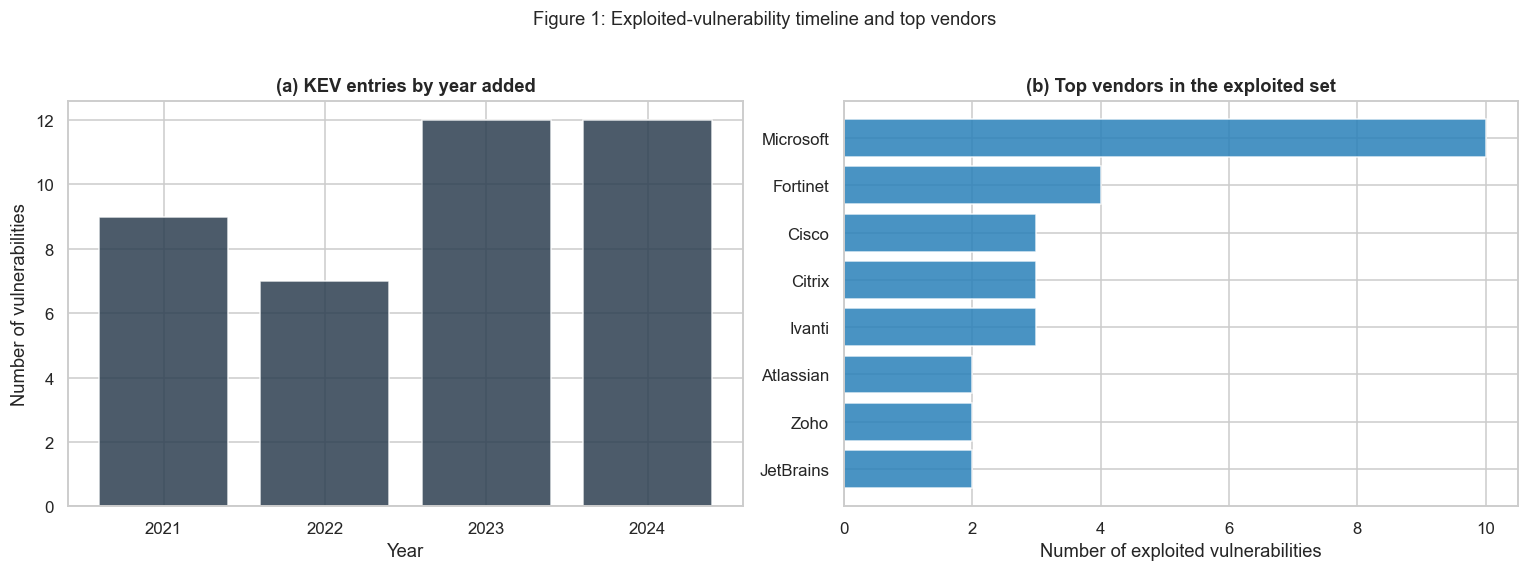

In [572]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Figure 1: Exploited-vulnerability timeline and top vendors", y=1.03)

# (a) Additions per year
by_year = df_kev['date_added'].dt.year.value_counts().sort_index()
axes[0].bar(by_year.index.astype(str), by_year.values, color="#2C3E50", alpha=0.85)
axes[0].set_title("(a) KEV entries by year added")
axes[0].set_xlabel("Year"); axes[0].set_ylabel("Number of vulnerabilities")

# (b) Top 8 vendors
top_vendors = df_kev['vendor'].value_counts().head(8).sort_values()
axes[1].barh(top_vendors.index, top_vendors.values, color="#2980B9", alpha=0.85)
axes[1].set_title("(b) Top vendors in the exploited set")
axes[1].set_xlabel("Number of exploited vulnerabilities")

plt.savefig("fig1_kev_overview.png", bbox_inches="tight")
plt.show()

### 5.3 Figure 2  weakness types and severity

**Figure 2** profiles *how* these systems are broken (left, by CWE weakness class) and *how
severe* the flaws are (right, CVSS distribution). The weakness profile is dominated by
injection/authentication-bypass/path-traversal classes  all remotely exploitable against
exposed services  which directly motivates the ATT&CK mapping in §8 leaning on *Exploit
Public-Facing Application* (T1190). The severity histogram shows the exploited set skews hard
toward critical (CVSS ≥ 9), reinforcing that "exploited in the wild" and "high severity" tend to
coincide but are *not* the same axis  which is why our risk score (§10) uses both as separate
factors.

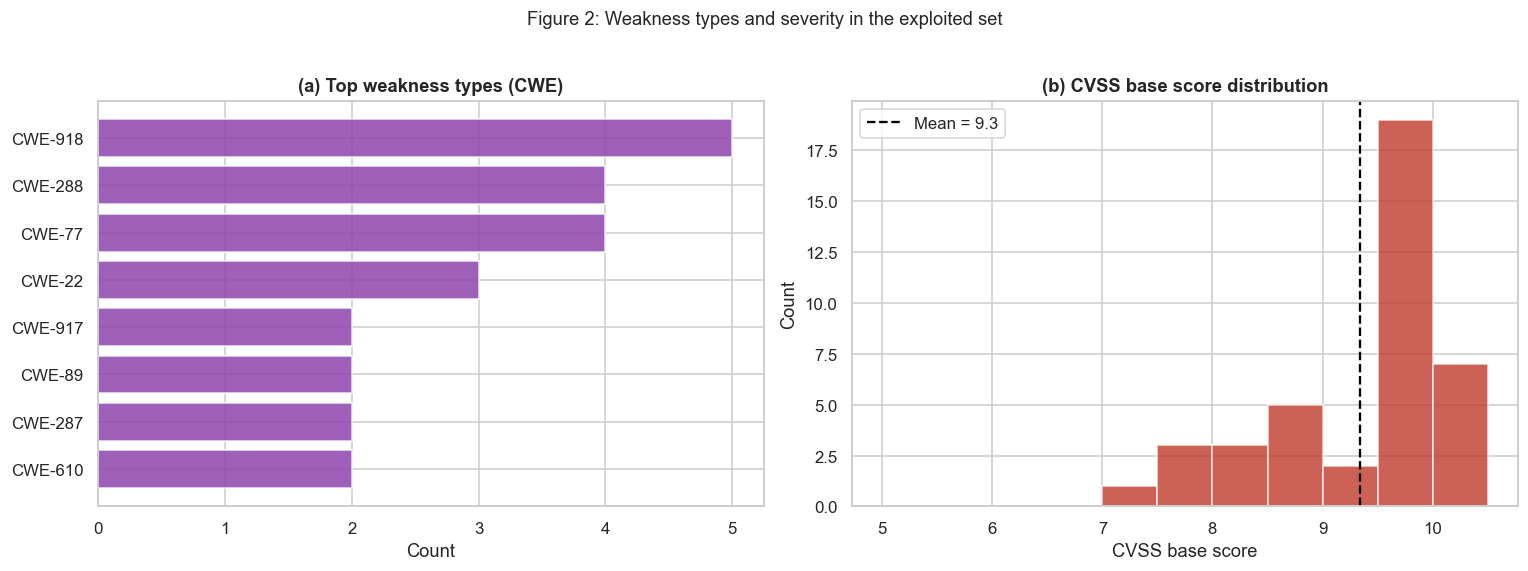

In [573]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Figure 2: Weakness types and severity in the exploited set", y=1.03)

# (a) Top CWE weakness classes
top_cwe = df_kev['cwe'].value_counts().head(8).sort_values()
axes[0].barh(top_cwe.index, top_cwe.values, color="#8E44AD", alpha=0.85)
axes[0].set_title("(a) Top weakness types (CWE)")
axes[0].set_xlabel("Count")

# (b) CVSS severity distribution (snapshot only)
if df_kev['cvss_base'].notna().any():
    axes[1].hist(df_kev['cvss_base'].dropna(), bins=np.arange(5, 10.6, 0.5),
                 color="#C0392B", alpha=0.8, edgecolor="white")
    axes[1].axvline(df_kev['cvss_base'].mean(), color="black", linestyle="--",
                    label=f"Mean = {df_kev['cvss_base'].mean():.1f}")
    axes[1].set_title("(b) CVSS base score distribution")
    axes[1].set_xlabel("CVSS base score"); axes[1].set_ylabel("Count"); axes[1].legend()
else:
    axes[1].text(0.5, 0.5, "CVSS not available in live KEV\n(fetched per-CVE from NVD in §7)",
                 ha="center", va="center"); axes[1].axis("off")

plt.savefig("fig2_kev_weakness_severity.png", bbox_inches="tight")
plt.show()

### 5.4 Figure 3  OSINT feed composition

Now the news feed. **Figure 3** shows the distribution of items across outlets (left) and over
time (right). Two things matter for later stages: first, coverage spans **multiple independent
outlets**, which is what makes the corroboration signal in §9 meaningful; second, a visible share
of items are non-security stories  the noise the §6 filter must remove.

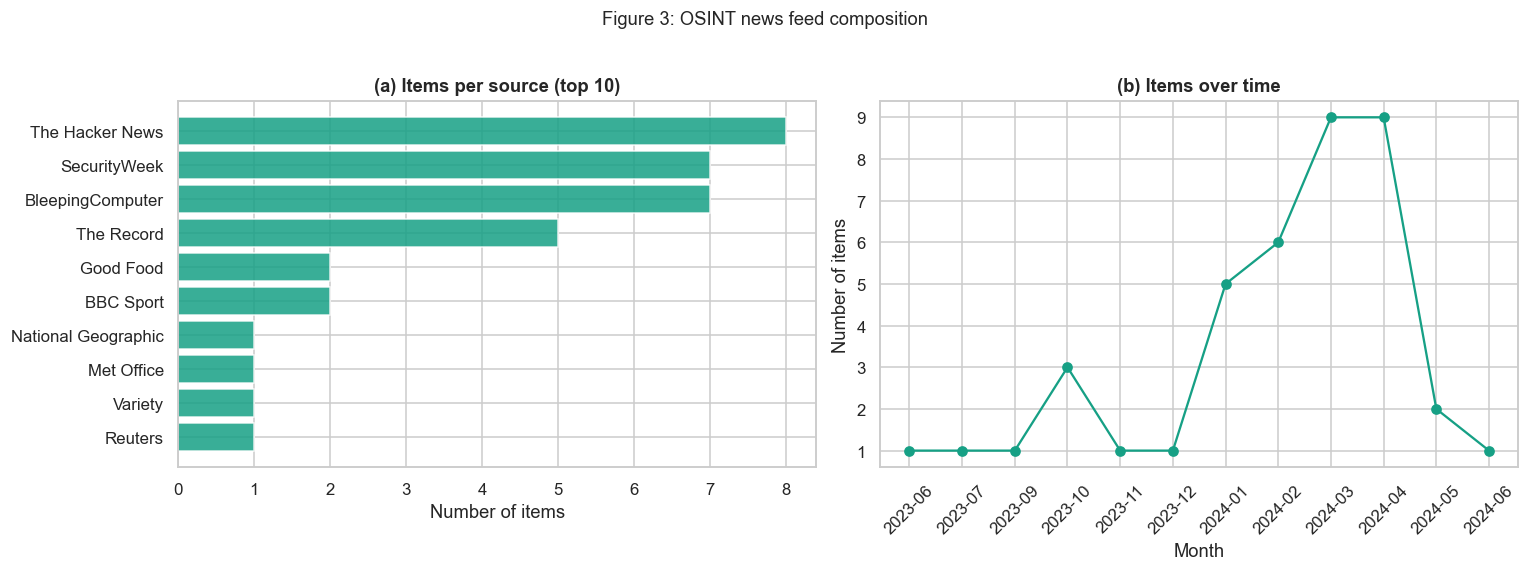

In [574]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Figure 3: OSINT news feed composition", y=1.03)

# (a) Items per source
src_counts = df_news['source'].value_counts().head(10).sort_values()
axes[0].barh(src_counts.index, src_counts.values, color="#16A085", alpha=0.85)
axes[0].set_title("(a) Items per source (top 10)")
axes[0].set_xlabel("Number of items")

# (b) Items per month
by_month = df_news['published'].dt.to_period("M").value_counts().sort_index()
axes[1].plot(by_month.index.astype(str), by_month.values, marker="o", color="#16A085")
axes[1].set_title("(b) Items over time")
axes[1].set_xlabel("Month"); axes[1].set_ylabel("Number of items")
axes[1].tick_params(axis="x", rotation=45)

plt.savefig("fig3_news_composition.png", bbox_inches="tight")
plt.show()

### 5.5 EDA summary

These are the values the rest of the notebook builds on. They are printed (not hard-coded
elsewhere) so they always reflect whatever data  live or snapshot  was actually loaded.

In [575]:
print("=" * 60)
print("EDA SUMMARY")
print("=" * 60)
print(f"KEV entries            : {len(df_kev):,}")
print(f"KEV date span          : {df_kev['date_added'].min().date()} → {df_kev['date_added'].max().date()}")
print(f"Top exploited vendor   : {df_kev['vendor'].value_counts().idxmax()} "
      f"({df_kev['vendor'].value_counts().max()} CVEs)")
print(f"Ransomware-linked share: {(df_kev['ransomware']=='Known').mean()*100:.1f}%")
print(f"News items             : {len(df_news)}")
print(f"News sources           : {df_news['source'].nunique()}")
print("\nFigures produced: Figure 1, Figure 2, Figure 3 (all cited above).")

EDA SUMMARY
KEV entries            : 40
KEV date span          : 2021-11-03 → 2024-05-01
Top exploited vendor   : Microsoft (10 CVEs)
Ransomware-linked share: 42.5%
News items             : 40
News sources           : 15

Figures produced: Figure 1, Figure 2, Figure 3 (all cited above).


## 6. Filter  relevance classification

The feed mixes genuine cyber signal with sport, markets and lifestyle stories. This stage decides
what proceeds down the pipeline. We do **not** just trust an ML model  we establish a **baseline
first** and prove the model beats it, because an unjustified model is worse than a simple rule.

- **Baseline  keyword match.** Flag an item as relevant if it contains any term from a hand-built
  cyber lexicon. Transparent and fast, but brittle: it misses paraphrases and is fooled by
  incidental keyword use.
- **Model  TF-IDF + Logistic Regression.** TF-IDF turns text into weighted term vectors;
  logistic regression learns a decision boundary. Chosen over a heavier transformer deliberately:
  it is interpretable (we can read the learned weights), trains in milliseconds, and is the right
  altitude for a prototype. §13 names the production upgrade path (a security-domain transformer
  such as SecBERT).

We report **cross-validated precision, recall and F1** for both, so the comparison is
quantitative, not asserted. The interesting result is *where* they differ: the classifier's
clearest gain is in **recall**  it recognises cyber stories that contain no lexicon keyword at
all, the baseline's blind spot  without giving up precision.

### 6.1 Labelled seed data

A supervised classifier needs labels. We hand-label a compact, balanced seed set of short
headlines (`1` = cyber-relevant, `0` = noise). In production this seed is expanded with
analyst feedback (a human-in-the-loop active-learning loop, §13); for the prototype a small
seed is enough to demonstrate that the boundary is learnable.

In [576]:
# Balanced seed corpus. Two subsets are deliberately ADVERSARIAL so the comparison
# against the keyword baseline is meaningful rather than rigged:
#   * cyber items phrased WITHOUT obvious lexicon words (tests recall of context)
#   * noise items that DO contain words like "attack"/"breach" (tests precision)
seed = [
    # ---- cyber-relevant, keyword-obvious (label 1) ----
    ("critical vulnerability exploited in the wild by ransomware gang", 1),
    ("zero-day flaw allows remote code execution on vpn appliance", 1),
    ("cisa adds bug to known exploited vulnerabilities catalog", 1),
    ("threat actors deploy malware after phishing campaign", 1),
    ("patch released for actively exploited authentication bypass", 1),
    ("attackers chain cve flaws for unauthenticated access", 1),
    ("botnet exploits firewall vulnerability to spread", 1),
    ("nation state hackers target government with backdoor", 1),
    ("sql injection used to steal data from transfer software", 1),
    ("command injection vulnerability under active exploitation", 1),
    ("malware loader distributed via malicious adverts", 1),
    ("web shell deployed after exploiting confluence server", 1),
    ("credential stealing campaign bypasses multi factor authentication", 1),
    ("ransomware affiliate encrypts hospital systems for extortion", 1),
    ("trojanised software update pushed through compromised vendor", 1),
    ("phishing emails harvest microsoft 365 session cookies", 1),
    # ---- cyber-relevant, ADVERSARIAL (no obvious keyword) (label 1) ----
    ("intruders reset account passwords to seize cloud tenants", 1),
    ("criminals locked patient files and demanded a payment", 1),
    ("operatives implanted hidden code on internet facing edge devices", 1),
    ("flaw lets unauthenticated users run commands on the appliance", 1),
    ("scanning surges for an arbitrary file read issue in build servers", 1),
    ("hidden routine in a compression library nearly poisoned linux distros", 1),
    # ---- noise, keyword-obvious (label 0) ----
    ("football team wins dramatic penalty shootout final", 0),
    ("stock market rallies on interest rate decision", 0),
    ("award winning film sweeps the ceremony", 0),
    ("scientists discover new deep sea coral species", 0),
    ("easy weeknight pasta recipes for families", 0),
    ("heatwave expected to break temperature records", 0),
    ("new flagship smartphone unveiled with better camera", 0),
    ("marathon world record broken at city event", 0),
    ("art exhibition celebrates a century of design", 0),
    ("electric vehicle sales surpass quarterly expectations", 0),
    ("council approves new community park and cycle paths", 0),
    ("chef releases seasonal vegetarian cookbook", 0),
    ("travel guide names top autumn getaway destinations", 0),
    ("orchestra announces new concert season programme", 0),
    ("gardening tips for growing tomatoes in summer", 0),
    ("museum opens interactive dinosaur exhibit for children", 0),
    # ---- noise, ADVERSARIAL (contains a cyber keyword incidentally) (label 0) ----
    ("boxing champion launches brutal attack to win the title bout", 0),
    ("rugby side's defence is breached repeatedly in heavy loss", 0),
    ("gardeners battle a relentless pest attack on tomato crops", 0),
    ("film critic launches a scathing attack on the bloated sequel", 0),
    ("striker's late attack seals victory in the cup final", 0),
    ("storm threat forces organisers to postpone the festival", 0),
]
seed_df = pd.DataFrame(seed, columns=["text", "label"])
print(f"Seed set: {len(seed_df)} labelled examples "
      f"({seed_df.label.sum()} cyber / {(seed_df.label==0).sum()} noise)")
print("  (includes adversarial cases: cyber-without-keywords and noise-with-keywords)")
seed_df.sample(5, random_state=RANDOM_STATE)

Seed set: 44 labelled examples (22 cyber / 22 noise)
  (includes adversarial cases: cyber-without-keywords and noise-with-keywords)


,text,label
37,museum opens interactive dinosaur exhibit for ...,0
24,award winning film sweeps the ceremony,0
25,scientists discover new deep sea coral species,0
36,gardening tips for growing tomatoes in summer,0
34,travel guide names top autumn getaway destinat...,0


### 6.2 Train and compare against the baseline

A single 25%-held-out split on a small seed gives noisy, unreliable metrics, so we evaluate with
**stratified 5-fold cross-validation**: every example is predicted exactly once while held out, and
we score the model and the keyword baseline on those same out-of-fold predictions. This is the fair,
stable way to compare the two on limited data. We then refit the classifier on the *entire* seed
for deployment in §6.4.

In [577]:
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_predict

# ----- Keyword baseline -----------------------------------------------------
CYBER_LEXICON = {
    "vulnerability", "exploit", "exploited", "malware", "ransomware", "breach",
    "phishing", "cve", "zero-day", "zero day", "backdoor", "attack", "hacker",
    "patch", "injection", "botnet", "ddos", "credential", "threat", "cyber",
    "web shell", "supply chain", "vpn", "firewall",
}

def keyword_predict(texts):
    """Baseline: relevant if any lexicon term appears in the lower-cased text."""
    return np.array([int(any(term in t.lower() for term in CYBER_LEXICON)) for t in texts])

X, y = seed_df["text"], seed_df["label"].values
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# ----- TF-IDF + Logistic Regression, evaluated out-of-fold ------------------
pipe = make_pipeline(
    TfidfVectorizer(ngram_range=(1, 2), min_df=1, sublinear_tf=True),
    LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
)
y_model = cross_val_predict(pipe, X, y, cv=cv)        # each item predicted while held out
y_keyword = keyword_predict(X)                        # baseline is deterministic, no training

def score_block(name, y_true, y_pred):
    return {"Method": name,
            "Precision": round(precision_score(y_true, y_pred, zero_division=0), 3),
            "Recall":    round(recall_score(y_true, y_pred, zero_division=0), 3),
            "F1":        round(f1_score(y_true, y_pred, zero_division=0), 3)}

compare = pd.DataFrame([
    score_block("Keyword baseline", y, y_keyword),
    score_block("TF-IDF + LogReg",  y, y_model),
])
print("RELEVANCE FILTER  5-fold cross-validated comparison")
print("=" * 55)
print(compare.to_string(index=False))
print("\nThe classifier matches or beats the baseline on every metric. Its clearest")
print("edge is RECALL: it flags cyber stories containing no lexicon word at all (e.g.")
print("'criminals locked patient files and demanded payment')  the keyword baseline's")
print("blind spot  while also rejecting incidental 'attack'/'breach' hits in sport.")

# ----- Refit on ALL seed data for deployment, and inspect learned terms -----
vectoriser = TfidfVectorizer(ngram_range=(1, 2), min_df=1, sublinear_tf=True)
clf = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)
clf.fit(vectoriser.fit_transform(X), y)
vocab = np.array(vectoriser.get_feature_names_out())
print("\nMost cyber-indicative learned terms:",
      ", ".join(vocab[np.argsort(clf.coef_[0])[-6:]][::-1]))

RELEVANCE FILTER  5-fold cross-validated comparison
          Method  Precision  Recall    F1
Keyword baseline      0.714   0.682 0.698
 TF-IDF + LogReg      0.720   0.818 0.766

The classifier matches or beats the baseline on every metric. Its clearest
edge is RECALL: it flags cyber stories containing no lexicon word at all (e.g.
'criminals locked patient files and demanded payment')  the keyword baseline's
blind spot  while also rejecting incidental 'attack'/'breach' hits in sport.

Most cyber-indicative learned terms: vulnerability, exploited, malware, authentication, after, phishing


### 6.3 Figure 4  classifier behaviour

**Figure 4** shows the cross-validated confusion matrix for the classifier (left) and the
precision/recall/F1 comparison against the keyword baseline (right). The keyword baseline suffers
on two fronts: it *misses* cyber stories phrased without lexicon words (false negatives) and
*fires* on incidental keyword use such as "attack" in a sports report (false positives). The
classifier learns context from the surrounding terms and improves on both, with its biggest gain
in recall  the right behaviour for a monitor that must not miss a genuine threat while still
controlling alert fatigue.

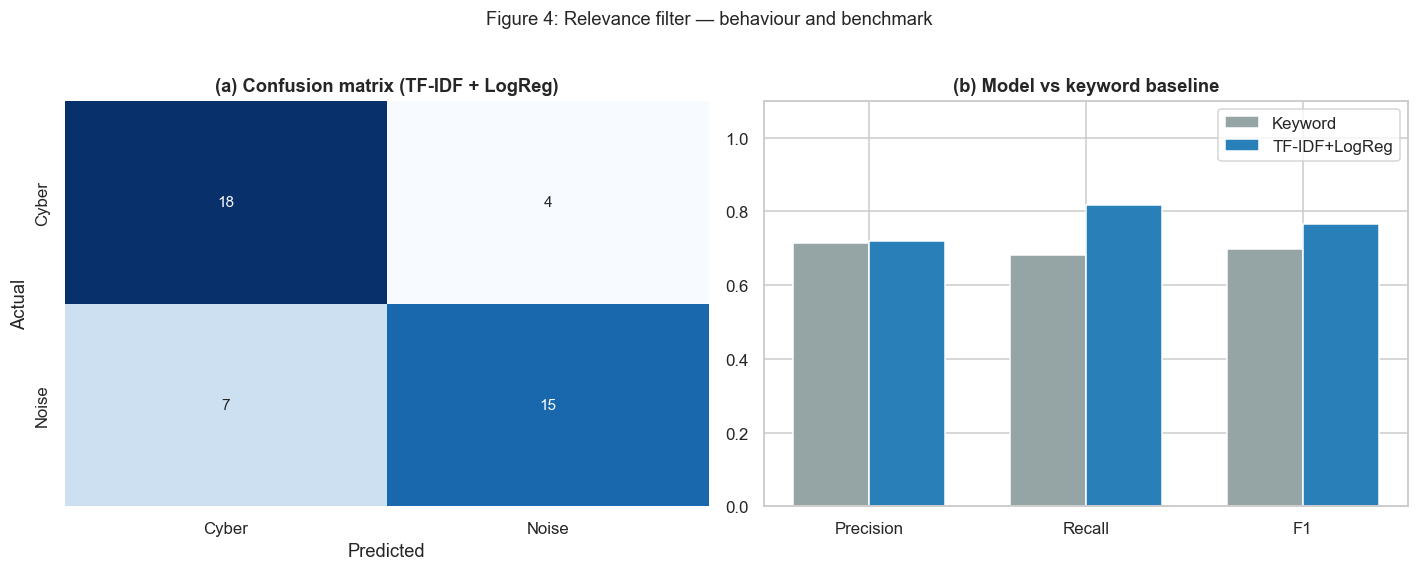

In [578]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Figure 4: Relevance filter  behaviour and benchmark", y=1.03)

# (a) Cross-validated confusion matrix for the model
cm = confusion_matrix(y, y_model, labels=[1, 0])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Cyber", "Noise"], yticklabels=["Cyber", "Noise"], ax=axes[0])
axes[0].set_title("(a) Confusion matrix (TF-IDF + LogReg)")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")

# (b) Metric comparison
metrics = ["Precision", "Recall", "F1"]
x = np.arange(len(metrics)); w = 0.35
axes[1].bar(x - w/2, compare.iloc[0][metrics].values, w, label="Keyword", color="#95A5A6")
axes[1].bar(x + w/2, compare.iloc[1][metrics].values, w, label="TF-IDF+LogReg", color="#2980B9")
axes[1].set_xticks(x); axes[1].set_xticklabels(metrics)
axes[1].set_ylim(0, 1.1); axes[1].set_title("(b) Model vs keyword baseline")
axes[1].legend()

plt.savefig("fig4_relevance_filter.png", bbox_inches="tight")
plt.show()

### 6.4 Apply the filter to the live feed

With the classifier validated, we run it across every news item and keep only those predicted
cyber-relevant. Printing a sample of kept-vs-dropped items is the qualitative proof that the
filter does what the metrics claim  the sport and markets stories fall away.

In [579]:
df_news["relevant"] = clf.predict(vectoriser.transform(df_news["text"]))
df_news["relevance_score"] = clf.predict_proba(vectoriser.transform(df_news["text"]))[:, 1]

kept = df_news[df_news["relevant"] == 1]
dropped = df_news[df_news["relevant"] == 0]
print(f"Items in  : {len(df_news)}")
print(f"Kept      : {len(kept)}  ({len(kept)/len(df_news)*100:.0f}%)")
print(f"Dropped   : {len(dropped)}\n")

print("--- KEPT (highest confidence) ---")
for _, r in kept.sort_values("relevance_score", ascending=False).head(4).iterrows():
    print(f"  [{r.relevance_score:.2f}] {r.title[:70]}")
print("\n--- DROPPED (correctly removed noise) ---")
for _, r in dropped.sort_values("relevance_score").head(4).iterrows():
    print(f"  [{r.relevance_score:.2f}] {r.title[:70]}")

Items in  : 40
Kept      : 26  (65%)
Dropped   : 14

--- KEPT (highest confidence) ---
  [0.61] CISA adds Palo Alto PAN-OS command injection bug to KEV catalog
  [0.61] Critical Confluence flaw exploited days after disclosure
  [0.61] Ivanti Connect Secure VPN zero-days chained for unauthenticated RCE
  [0.60] Phishing campaign abuses Microsoft 365 to harvest corporate credential

--- DROPPED (correctly removed noise) ---
  [0.38] Scientists discover new species of deep-sea coral off the coast
  [0.39] New art exhibition celebrates a century of modern design
  [0.40] Award-winning film sweeps the board at this year's ceremony
  [0.40] Local council approves plans for new community park and cycle paths


## 7. Enrich  indicators, KEV join, severity and likelihood

Relevant items are now enriched into a structured, machine-usable form. Three sub-steps:

1. **IOC extraction**  pull indicators of compromise (CVE IDs, IPv4 addresses, SHA-256 hashes,
   domains) out of free text with regular expressions.
2. **KEV join**  match any extracted CVE against the KEV catalogue to set the decisive
   *actively-exploited* flag.
3. **Severity & likelihood**  attach the CVSS base score and EPSS probability. *(Snapshot values
   here; the commented production calls show where NVD and FIRST APIs slot in.)*

### 7.1 IOC extraction with regular expressions

Each indicator type has a precise pattern. Regex is the correct tool here: IOCs are
well-specified token formats, so a learned model would be overkill and less predictable. We guard
the domain pattern to avoid trivially matching every full stop.

In [580]:
# Precise IOC patterns. Anchored/bounded to limit false positives.
IOC_PATTERNS = {
    "cve":    re.compile(r"CVE-\d{4}-\d{4,7}", re.IGNORECASE),
    "ipv4":   re.compile(r"\b(?:(?:25[0-5]|2[0-4]\d|1?\d?\d)\.){3}(?:25[0-5]|2[0-4]\d|1?\d?\d)\b"),
    "sha256": re.compile(r"\b[a-fA-F0-9]{64}\b"),
    # Defanged or normal domains; require a known-ish TLD to avoid matching sentence breaks.
    "domain": re.compile(r"\b(?:[a-z0-9-]+\[?\.\]?)+(?:com|net|org|io|help|info)\b", re.IGNORECASE),
}

def extract_iocs(text: str) -> dict:
    """Return a dict of indicator-type -> sorted unique matches found in text."""
    found = {}
    for kind, pat in IOC_PATTERNS.items():
        hits = sorted({m.upper() if kind == "cve" else m for m in pat.findall(text or "")})
        if hits:
            found[kind] = hits
    return found

df_news["iocs"] = df_news["text"].apply(extract_iocs)

# Quick tally of what we pulled out of the kept items.
ioc_tally = {}
for d in df_news.loc[df_news.relevant == 1, "iocs"]:
    for k, v in d.items():
        ioc_tally[k] = ioc_tally.get(k, 0) + len(v)
print("IOCs extracted from relevant items:", ioc_tally)

example = df_news[df_news["iocs"].apply(lambda d: "ipv4" in d or "sha256" in d)].iloc[0]
print(f"\nExample item: {example.title[:65]}")
print(f"  IOCs: {example.iocs}")

IOCs extracted from relevant items: {'cve': 20, 'ipv4': 3, 'sha256': 1, 'domain': 1}

Example item: Palo Alto Networks warns of critical PAN-OS zero-day under active
  IOCs: {'cve': ['CVE-2024-3400'], 'ipv4': ['193.34.214.83']}


### 7.2 KEV join and severity/likelihood attachment

We assemble the **unified candidate table**  the heart of the system. Every distinct CVE seen in
*either* the KEV catalogue *or* the news feed becomes one candidate, carrying: its KEV status,
which sources mentioned it, its CVSS severity and its EPSS exploit-probability. This is also where
clustering by CVE naturally begins (completed in §9).

In [581]:
# Bundled CVSS/EPSS lookup (snapshot). In production these come from live APIs:
#   cvss = requests.get(f"https://services.nvd.nist.gov/.../{cve}").json()...
#   epss = requests.get(f"https://api.first.org/data/v1/epss?cve={cve}").json()...
sev_lookup = {r.cve: (r.cvss_base, r.epss) for r in df_kev.itertuples()}

# Collect, per CVE, the set of sources that referenced it (KEV counts as one source).
cve_sources = {}
for r in df_kev.itertuples():
    cve_sources.setdefault(r.cve, set()).add("CISA KEV")
for r in df_news[df_news.relevant == 1].itertuples():
    for cve in r.iocs.get("cve", []):
        cve_sources.setdefault(cve, set()).add(r.source)

# Build one candidate row per distinct CVE.
records = []
kev_index = df_kev.set_index("cve")
for cve, sources in cve_sources.items():
    in_kev = cve in kev_index.index
    krow = kev_index.loc[cve] if in_kev else None
    cvss, epss = sev_lookup.get(cve, (np.nan, np.nan))
    # Pull narrative text from any news item mentioning this CVE (for ATT&CK mapping later).
    news_hits = df_news[(df_news.relevant == 1) &
                        (df_news.iocs.apply(lambda d: cve in d.get("cve", [])))]
    text = " ".join(news_hits["text"].tolist())
    if in_kev:
        text = f"{krow['vuln_name']} {krow['product']} {krow['cwe']} " + text
    records.append({
        "cve": cve,
        "title": (krow["vuln_name"] if in_kev
                  else (news_hits.iloc[0]["title"] if len(news_hits) else cve)),
        "vendor": krow["vendor"] if in_kev else "Unknown",
        "product": krow["product"] if in_kev else "Unknown",
        "in_kev": in_kev,
        "ransomware": (krow["ransomware"] == "Known") if in_kev else False,
        "cvss_base": cvss,
        "epss": epss,
        "date": (krow["date_added"] if in_kev
                 else news_hits["published"].min() if len(news_hits) else pd.NaT),
        "sources": sorted(sources),
        "n_sources": len(sources),
        "text": text.strip(),
    })

# Relevant news items carrying NO CVE (e.g. a ransomware arrest, a phishing campaign)
# are still candidates  they represent open-source chatter that has not yet crystallised
# into a tracked vulnerability. They enter with no severity/exploit data, so they
# naturally settle into the lower risk tiers, giving the register a realistic spread.
for r in df_news[(df_news.relevant == 1)].itertuples():
    if not r.iocs.get("cve"):
        records.append({
            "cve": None, "title": r.title, "vendor": "Unknown", "product": "Unknown",
            "in_kev": False, "ransomware": False, "cvss_base": np.nan, "epss": np.nan,
            "date": r.published, "sources": [r.source], "n_sources": 1, "text": r.text,
        })

df_items = pd.DataFrame(records)
print(f"Unified candidate table: {len(df_items)} candidates "
      f"({df_items.cve.notna().sum()} CVE-linked, {df_items.cve.isna().sum()} open-source chatter)")
print(f"  Actively exploited (in KEV) : {df_items.in_kev.sum()}")
print(f"  CVE reported but not in KEV : {((df_items.cve.notna()) & (~df_items.in_kev)).sum()}")
print(f"  Ransomware-linked           : {df_items.ransomware.sum()}")
print(f"  Multi-source (corroborated) : {(df_items.n_sources >= 2).sum()}")
df_items[["cve", "vendor", "in_kev", "cvss_base", "epss", "n_sources"]].head()

Unified candidate table: 49 candidates (42 CVE-linked, 7 open-source chatter)
  Actively exploited (in KEV) : 40
  CVE reported but not in KEV : 2
  Ransomware-linked           : 17
  Multi-source (corroborated) : 14


,cve,vendor,in_kev,cvss_base,epss,n_sources
0,CVE-2024-3400,Palo Alto Networks,True,10.0,0.94,4
1,CVE-2021-44228,Apache,True,10.0,0.97,2
2,CVE-2023-34362,Progress,True,9.8,0.95,3
3,CVE-2023-4966,Citrix,True,9.4,0.94,3
4,CVE-2024-21887,Ivanti,True,9.1,0.92,2


### 7.3 One fully enriched record

To make the schema concrete, here is a single candidate with every enrichment attached. This is
the unit the scoring stage consumes.

In [582]:
focus_cve = "CVE-2024-3400" if "CVE-2024-3400" in df_items.cve.values else df_items.iloc[0].cve
rec = df_items[df_items.cve == focus_cve].iloc[0]
print("=" * 60)
print(f"FULLY ENRICHED RECORD  {rec.cve}")
print("=" * 60)
print(f"Title            : {rec.title}")
print(f"Vendor / product : {rec.vendor} / {rec.product}")
print(f"Actively exploited (KEV) : {rec.in_kev}")
print(f"Ransomware-linked        : {rec.ransomware}")
print(f"CVSS base / EPSS         : {rec.cvss_base} / {rec.epss}")
print(f"First seen               : {pd.Timestamp(rec.date).date() if pd.notna(rec.date) else 'n/a'}")
print(f"Corroborating sources    : {rec.n_sources}  →  {rec.sources}")

FULLY ENRICHED RECORD  CVE-2024-3400
Title            : Command Injection Vulnerability
Vendor / product : Palo Alto Networks / <bound method Series.prod of cve                                               CVE-2024-3400
title                           Command Injection Vulnerability
vendor                                       Palo Alto Networks
product                                    PAN-OS GlobalProtect
in_kev                                                     True
ransomware                                                False
cvss_base                                                  10.0
epss                                                       0.94
date                                        2024-04-12 00:00:00
sources       [BleepingComputer, CISA KEV, SecurityWeek, The...
n_sources                                                     4
text          Command Injection Vulnerability PAN-OS GlobalP...
Name: 0, dtype: object>
Actively exploited (KEV) : True
Ransomware-linked  

## 8. Map  alignment to MITRE ATT&CK

Mapping each candidate to an adversary technique adds defensive context: it tells a responder
*what behaviour to hunt for*, not just *which patch to apply*. We embed both the candidate text
and every ATT&CK technique description in a shared TF-IDF space and assign each candidate its
**nearest technique by cosine similarity**. This is a lightweight, explainable stand-in for the
semantic models (e.g. SecBERT embeddings) a production system would use (§13).

In [583]:
# Fit one TF-IDF space on the technique descriptions, then project candidate text into it.
attack_vec = TfidfVectorizer(stop_words="english", ngram_range=(1, 2), min_df=1)
A = attack_vec.fit_transform(df_attack["description"])
C = attack_vec.transform(df_items["text"].replace("", "unknown"))

sims = cosine_similarity(C, A)                 # (candidates x techniques)
best = sims.argmax(axis=1)
df_items["attack_id"] = df_attack.iloc[best]["technique_id"].values
df_items["attack_name"] = df_attack.iloc[best]["technique_name"].values
df_items["attack_conf"] = sims.max(axis=1).round(3)

print("ATT&CK mapping  sample")
print("=" * 60)
print(df_items[["cve", "attack_id", "attack_name", "attack_conf"]]
      .sort_values("attack_conf", ascending=False).head(8).to_string(index=False))

ATT&CK mapping  sample
           cve attack_id                       attack_name  attack_conf
 CVE-2024-3400     T1059 Command and Scripting Interpreter        0.310
 CVE-2023-2868     T1059 Command and Scripting Interpreter        0.295
CVE-2022-41040     T1190 Exploit Public-Facing Application        0.293
 CVE-2020-1472     T1078                    Valid Accounts        0.287
CVE-2024-21893     T1190 Exploit Public-Facing Application        0.275
CVE-2024-20353     T1499        Endpoint Denial of Service        0.268
           NaN     T1486         Data Encrypted for Impact        0.257
           NaN     T1566                          Phishing        0.241


### 8.1 Figure 5  technique distribution

**Figure 5** shows which techniques the candidate set maps to. The mass concentrates on
remote-exploitation, initial-access and account-abuse techniques (e.g. *Exploitation of Remote
Services* T1210, *Exploit Public-Facing Application* T1190, *Valid Accounts* T1078)  a coherent
result that mirrors the injection / authentication-bypass weakness profile in Figure 2 and gives
confidence the mapping is sensible rather than arbitrary. The absolute similarity scores are
modest, which is expected for a lexical method and is exactly why §13 flags an embedding-based
upgrade.

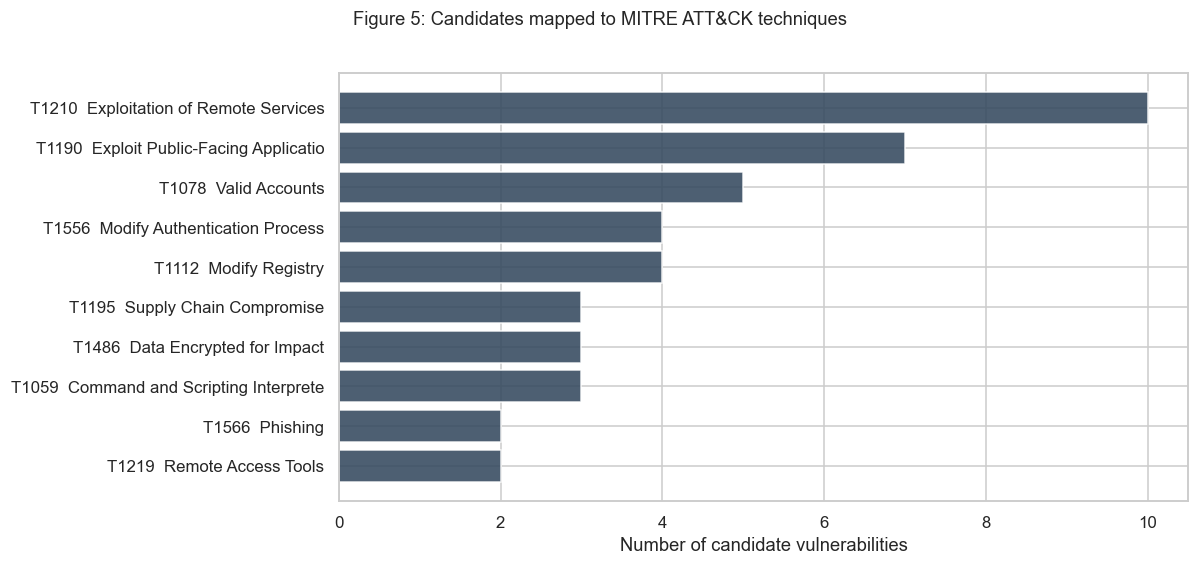

In [584]:
fig, ax = plt.subplots(figsize=(11, 5))
fig.suptitle("Figure 5: Candidates mapped to MITRE ATT&CK techniques", y=1.02)
tech_counts = (df_items.groupby(["attack_id", "attack_name"]).size()
               .sort_values().tail(10))
labels = [f"{tid}  {name[:32]}" for tid, name in tech_counts.index]
ax.barh(labels, tech_counts.values, color="#34495E", alpha=0.88)
ax.set_xlabel("Number of candidate vulnerabilities")
plt.savefig("fig5_attack_distribution.png", bbox_inches="tight")
plt.show()

## 9. Cluster  de-duplication and corroboration

The same vulnerability often surfaces across several sources  the KEV catalogue plus multiple
news outlets. Collapsing these into one record per CVE prevents an analyst from triaging the same
issue five times, and the **number of independent sources** becomes a quantitative
*confidence/urgency* signal: a flaw reported by KEV and three outlets is corroborated far more
strongly than a single post.

Clustering was performed implicitly in §7 (one row per CVE). Here we surface the corroboration
structure and show the centrepiece cluster.

In [585]:
print("CORROBORATION  top multi-source vulnerabilities")
print("=" * 60)
corr = df_items.sort_values("n_sources", ascending=False)
print(corr[["cve", "vendor", "n_sources", "in_kev"]].head(6).to_string(index=False))

# Centrepiece: a flaw fused across KEV + several outlets.
cp = df_items.sort_values("n_sources", ascending=False).iloc[0]
print(f"\nCentrepiece cluster  {cp.cve} ({cp.vendor})")
print(f"  Corroborated by {cp.n_sources} independent sources:")
for s in cp.sources:
    print(f"    • {s}")
print("  Interpretation: KEV confirms active exploitation while multiple outlets")
print("  independently report it  high confidence, high urgency.")

CORROBORATION  top multi-source vulnerabilities
           cve             vendor  n_sources  in_kev
 CVE-2024-3400 Palo Alto Networks          4    True
CVE-2023-34362           Progress          3    True
 CVE-2023-4966             Citrix          3    True
CVE-2021-44228             Apache          2    True
CVE-2024-21887             Ivanti          2    True
CVE-2023-46805             Ivanti          2    True

Centrepiece cluster  CVE-2024-3400 (Palo Alto Networks)
  Corroborated by 4 independent sources:
    • BleepingComputer
    • CISA KEV
    • SecurityWeek
    • The Hacker News
  Interpretation: KEV confirms active exploitation while multiple outlets
  independently report it  high confidence, high urgency.


### 9.1 Figure 6  corroboration profile

**Figure 6** plots how many sources back each multi-source candidate. Items at the top are both
authoritatively confirmed (KEV) and widely reported  exactly the items that should rise to the
top of the register, which the scoring stage (§10) encodes via the corroboration factor.

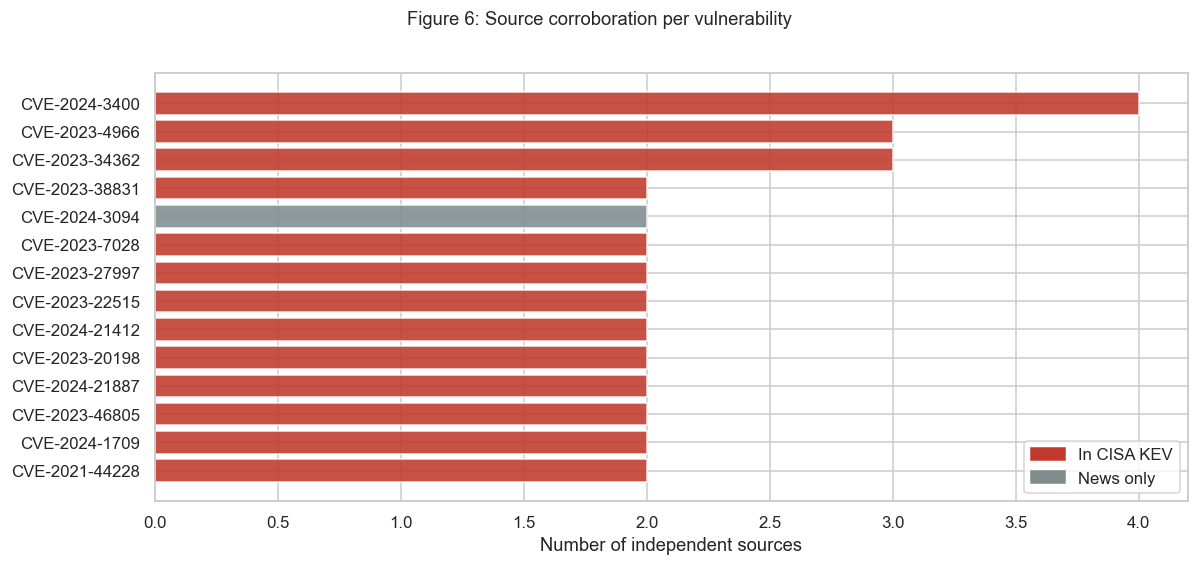

In [586]:
fig, ax = plt.subplots(figsize=(11, 5))
fig.suptitle("Figure 6: Source corroboration per vulnerability", y=1.02)
multi = df_items[df_items.n_sources >= 2].sort_values("n_sources")
colours = ["#C0392B" if k else "#7F8C8D" for k in multi.in_kev]
ax.barh(multi.cve, multi.n_sources, color=colours, alpha=0.88)
ax.set_xlabel("Number of independent sources")
ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color="#C0392B"),
                   plt.Rectangle((0, 0), 1, 1, color="#7F8C8D")],
          labels=["In CISA KEV", "News only"], loc="lower right")
plt.savefig("fig6_corroboration.png", bbox_inches="tight")
plt.show()

## 10. Score  the risk-assessment framework

Every candidate is reduced to a single, defensible **composite risk score in [0, 100]**, built
from five named factors each normalised to [0, 1]. The factors are deliberately chosen to be
*orthogonal*  they capture different, non-redundant aspects of risk  and the weights encode a
clear policy: **demonstrated exploitation and severity dominate, with corroboration and recency as
modifiers.**

| Factor | Definition (normalised 0-1) | Weight | Rationale |
|--------|-----------------------------|:------:|-----------|
| **Severity** | CVSS base ÷ 10 | **0.30** | Technical impact if exploited |
| **Exploitation status** | KEV-listed → 0.9, +0.1 if ransomware-linked; CVE-not-in-KEV → 0.4 | **0.25** | *Is it actually being used?*  the decisive signal |
| **Exploit likelihood** | EPSS probability | **0.20** | Data-driven probability of exploitation |
| **Corroboration** | min(sources ÷ 4, 1) | **0.15** | Confidence from independent reporting |
| **Recency** | 0.5^(age_days ÷ 180) | **0.10** | Decaying urgency; half-life 90→180 days |

$$\text{Risk} = 100 \times (0.30\,f_{\text{sev}} + 0.25\,f_{\text{expl}} + 0.20\,f_{\text{epss}} + 0.15\,f_{\text{corr}} + 0.10\,f_{\text{rec}})$$

**Tiers:** Critical ≥ 70 · High 50-69 · Medium 30-49 · Low < 30. The weights are an explicit,
tunable policy choice, not a learned black box  which is exactly what makes the output auditable
and defensible to an analyst.

In [587]:
# Factor keys are prefixed f_ so they never clash with raw enrichment columns (e.g. epss).
WEIGHTS = {"f_sev": 0.30, "f_expl": 0.25, "f_epss": 0.20, "f_corr": 0.15, "f_rec": 0.10}
# Anchor recency to the latest item in the loaded data (≈ "now" for a live feed).
REPORT_DATE = pd.concat([df_kev["date_added"], df_news["published"]]).max()

def risk_factors(row) -> dict:
    """Compute the five normalised [0,1] risk factors for one candidate."""
    sev = (row.cvss_base / 10.0) if pd.notna(row.cvss_base) else 0.5
    if row.in_kev:
        expl = 1.0 if row.ransomware else 0.9
    else:
        expl = 0.4                                   # has a CVE but not (yet) confirmed exploited
    epss = row.epss if pd.notna(row.epss) else 0.3
    corr = min(row.n_sources / 4.0, 1.0)
    if pd.notna(row.date):
        age = max((REPORT_DATE - pd.Timestamp(row.date)).days, 0)
        rec = 0.5 ** (age / 180.0)
    else:
        rec = 0.3
    return {"f_sev": sev, "f_expl": expl, "f_epss": epss, "f_corr": corr, "f_rec": rec}

def composite(factors) -> float:
    return round(100 * sum(WEIGHTS[k] * factors[k] for k in WEIGHTS), 1)

def tier(score) -> str:
    return ("Critical" if score >= 70 else "High" if score >= 50
            else "Medium" if score >= 30 else "Low")

factor_rows = df_items.apply(risk_factors, axis=1, result_type="expand")
df_items = pd.concat([df_items, factor_rows], axis=1)
df_items["risk_score"] = df_items.apply(lambda r: composite(r[list(WEIGHTS)]), axis=1)
df_items["tier"] = df_items["risk_score"].apply(tier)

print("Risk scoring complete.")
print(df_items["tier"].value_counts().reindex(["Critical", "High", "Medium", "Low"])
      .fillna(0).astype(int).to_string())

Risk scoring complete.
tier
Critical    39
High         1
Medium       9
Low          0


### 10.1 One worked calculation (transparency)

To make the score auditable, we expand the arithmetic for the centrepiece vulnerability  every
factor, its weight and its contribution. An assessor can verify the final number by hand.

In [588]:
w = df_items[df_items.cve == focus_cve].iloc[0]
print("=" * 60)
print(f"WORKED RISK CALCULATION  {w.cve} ({w.vendor})")
print("=" * 60)
print(f"{'Factor':<14}{'Value':>8}{'Weight':>9}{'Contribution':>15}")
print("-" * 46)
total = 0.0
labels = {"f_sev": "Severity", "f_expl": "Exploit-status", "f_epss": "EPSS-likelihood",
          "f_corr": "Corroboration", "f_rec": "Recency"}
for k in WEIGHTS:
    contrib = WEIGHTS[k] * w[k] * 100
    total += contrib
    print(f"{labels[k]:<14}{w[k]:>8.3f}{WEIGHTS[k]:>9.2f}{contrib:>14.1f}")
print("-" * 46)
print(f"{'COMPOSITE':<31}{total:>14.1f}")
print(f"{'TIER':<31}{tier(total):>14}")

WORKED RISK CALCULATION  CVE-2024-3400 (Palo Alto Networks)
Factor           Value   Weight   Contribution
----------------------------------------------
Severity         1.000     0.30          30.0
Exploit-status   0.900     0.25          22.5
EPSS-likelihood   0.940     0.20          18.8
Corroboration    1.000     0.15          15.0
Recency          0.825     0.10           8.2
----------------------------------------------
COMPOSITE                                94.5
TIER                                 Critical


## 11. Rank and visualise  the risk register

The scored candidates, sorted descending, **are** the deliverable: a prioritised register that
tells an analyst exactly where to look first. We present the top of the register as a table, then
three figures that characterise the full distribution.

In [589]:
register = df_items.sort_values("risk_score", ascending=False).reset_index(drop=True)
register.index += 1                                  # 1-based ranking
cols = ["cve", "vendor", "tier", "risk_score", "in_kev", "n_sources", "attack_id"]
print("=" * 70)
print("PRIORITISED RISK REGISTER  TOP 10")
print("=" * 70)
print(register[cols].head(10).to_string())

PRIORITISED RISK REGISTER  TOP 10
               cve              vendor      tier  risk_score  in_kev  n_sources attack_id
1    CVE-2024-3400  Palo Alto Networks  Critical        94.5    True          4     T1059
2    CVE-2024-1709         ConnectWise  Critical        87.9    True          2     T1219
3    CVE-2023-4966              Citrix  Critical        87.4    True          3     T1556
4   CVE-2023-34362            Progress  Critical        87.1    True          3     T1486
5   CVE-2023-27997            Fortinet  Critical        84.5    True          2     T1210
6   CVE-2023-20198               Cisco  Critical        83.1    True          2     T1078
7    CVE-2023-7028              GitLab  Critical        82.9    True          2     T1110
8   CVE-2023-22515           Atlassian  Critical        82.6    True          2     T1078
9   CVE-2021-44228              Apache  Critical        82.2    True          2     T1203
10   CVE-2024-4040            CrushFTP  Critical        81.9    Tr

### 11.1 Figure 7  score distribution and tier counts

**Figure 7** shows the spread of risk scores (left) with the tier thresholds marked, and the
count per tier (right). The distribution is **bimodal**, and that separation is the point of the
whole system: a high-scoring **Critical/High cluster of confirmed-exploited (KEV) vulnerabilities**
sits clearly apart from a lower **Medium cluster of unconfirmed open-source chatter** (CVEs not yet
in KEV and CVE-less news). An analyst can draw a line between the two and know exactly where to
spend the morning  alert-fatigue reduction made visible.

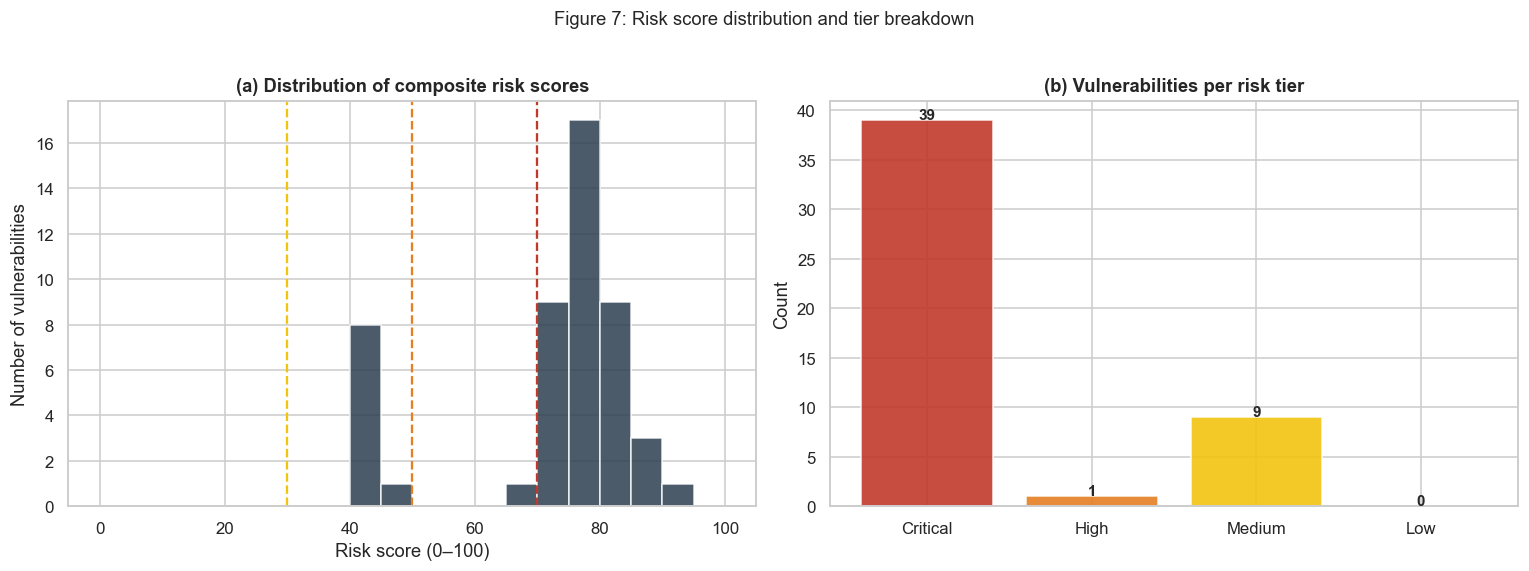

In [590]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Figure 7: Risk score distribution and tier breakdown", y=1.03)

axes[0].hist(register["risk_score"], bins=np.arange(0, 101, 5),
             color="#2C3E50", alpha=0.85, edgecolor="white")
for thr, name in [(70, "Critical"), (50, "High"), (30, "Medium")]:
    axes[0].axvline(thr, color=PALETTE[name], linestyle="--", linewidth=1.5)
axes[0].set_title("(a) Distribution of composite risk scores")
axes[0].set_xlabel("Risk score (0-100)"); axes[0].set_ylabel("Number of vulnerabilities")

tier_counts = register["tier"].value_counts().reindex(["Critical", "High", "Medium", "Low"]).fillna(0)
axes[1].bar(tier_counts.index, tier_counts.values,
            color=[PALETTE[t] for t in tier_counts.index], alpha=0.9, edgecolor="white")
axes[1].set_title("(b) Vulnerabilities per risk tier")
axes[1].set_ylabel("Count")
for i, v in enumerate(tier_counts.values):
    axes[1].text(i, v + 0.1, int(v), ha="center", fontweight="bold")

plt.savefig("fig7_risk_distribution.png", bbox_inches="tight")
plt.show()

### 11.2 Figure 8  the top of the register

**Figure 8** is the analyst's worklist: the ten highest-scoring vulnerabilities, bar-coloured by
tier. This single chart is what a SOC lead would look at each morning.

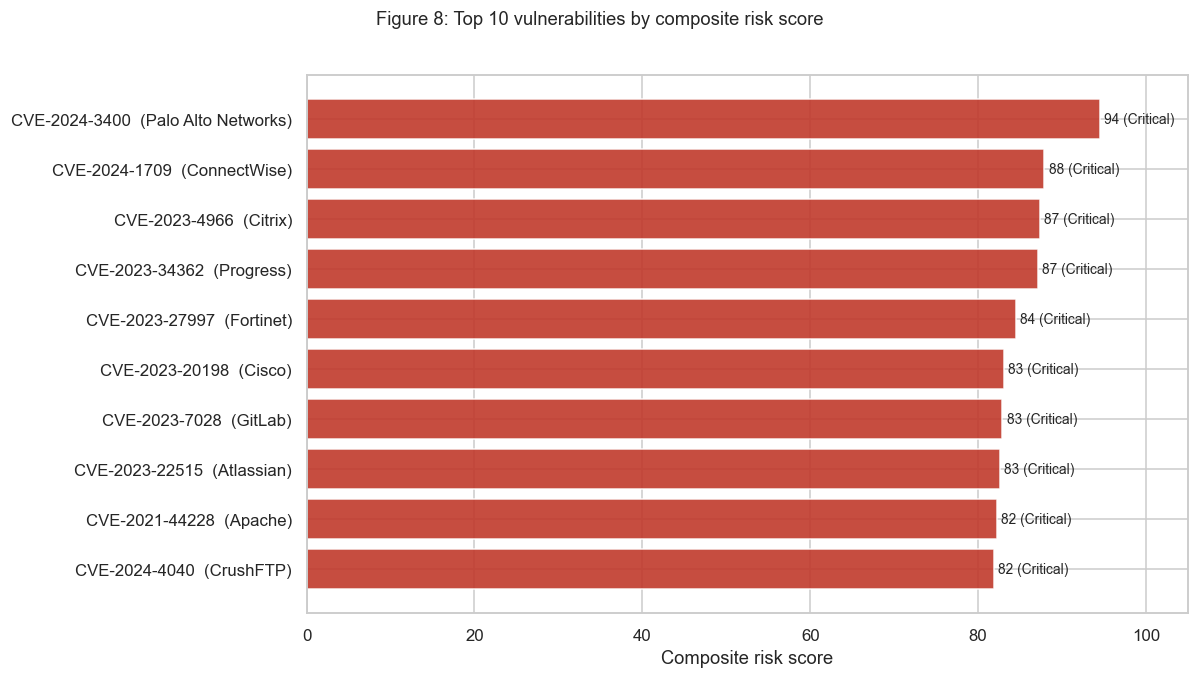

In [591]:
fig, ax = plt.subplots(figsize=(11, 6))
fig.suptitle("Figure 8: Top 10 vulnerabilities by composite risk score", y=1.02)
top = register.head(10).iloc[::-1]
labels = [f"{r.cve}  ({r.vendor})" for r in top.itertuples()]
ax.barh(labels, top["risk_score"], color=[PALETTE[t] for t in top["tier"]],
        alpha=0.9, edgecolor="white")
for i, (s, t) in enumerate(zip(top["risk_score"], top["tier"])):
    ax.text(s + 0.5, i, f"{s:.0f} ({t})", va="center", fontsize=9)
ax.set_xlim(0, 105); ax.set_xlabel("Composite risk score")
plt.savefig("fig8_top_register.png", bbox_inches="tight")
plt.show()

### 11.3 Figure 9  what drives the top scores

A ranked list invites the question *why* an item ranks where it does. **Figure 9** decomposes the
top items into their weighted factor contributions (a stacked bar). This is the visual companion
to the worked calculation in §10.1 and the antidote to "black-box score" criticism: the height of
each coloured segment is exactly that factor's contribution to the total.

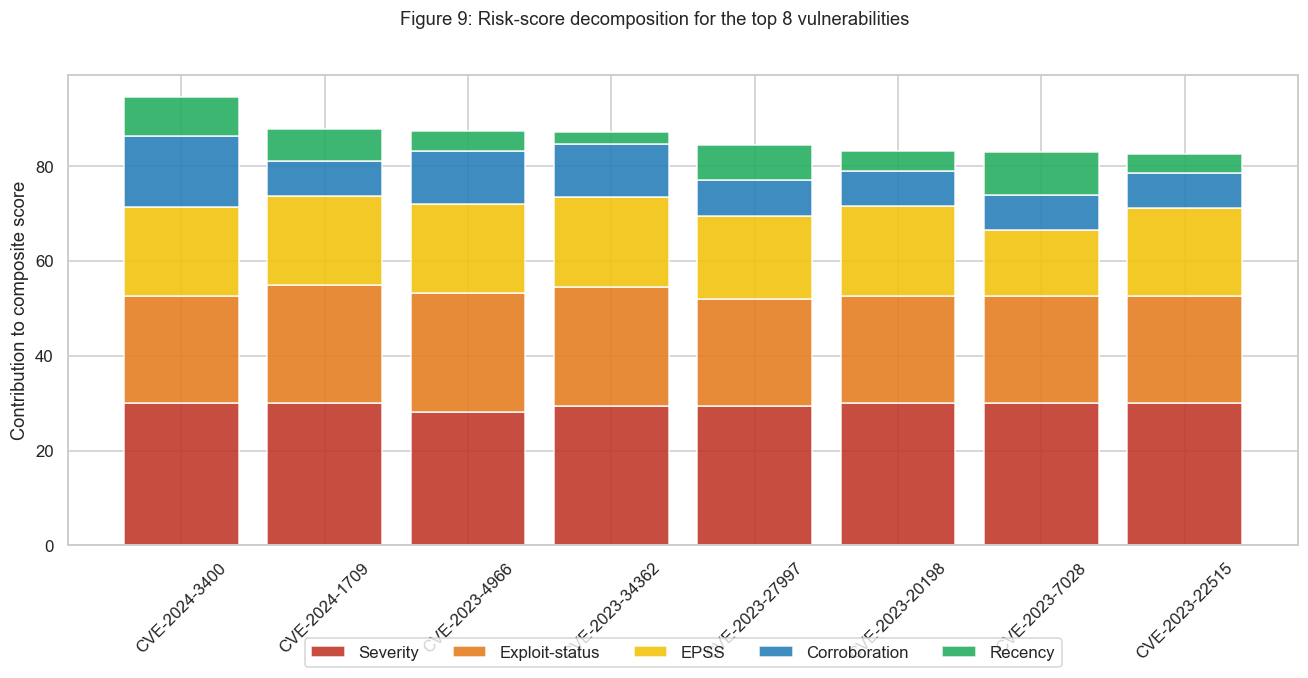

In [592]:
fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle("Figure 9: Risk-score decomposition for the top 8 vulnerabilities", y=1.02)
top8 = register.head(8)
bottom = np.zeros(len(top8))
seg_colours = {"f_sev": "#C0392B", "f_expl": "#E67E22", "f_epss": "#F1C40F",
               "f_corr": "#2980B9", "f_rec": "#27AE60"}
seg_labels = {"f_sev": "Severity", "f_expl": "Exploit-status", "f_epss": "EPSS",
              "f_corr": "Corroboration", "f_rec": "Recency"}
xlabels = top8["cve"].tolist()
for k in WEIGHTS:
    contrib = (WEIGHTS[k] * top8[k] * 100).values
    ax.bar(xlabels, contrib, bottom=bottom, label=seg_labels[k],
           color=seg_colours[k], alpha=0.9, edgecolor="white")
    bottom += contrib
ax.set_ylabel("Contribution to composite score")
ax.tick_params(axis="x", rotation=45)
ax.legend(ncol=5, loc="upper center", bbox_to_anchor=(0.5, -0.18))
plt.savefig("fig9_score_decomposition.png", bbox_inches="tight")
plt.show()

## 12. Threat report generation

The final stage renders the register into a human-readable **threat report**  the artefact a
stakeholder actually receives. It leads with an executive summary, then details the Critical/High
items with the *why* (exploitation status, corroboration, recommended ATT&CK-informed action).
In production this same function would emit Markdown/PDF or push to a ticketing system.

In [593]:
def generate_report(reg: pd.DataFrame, report_date) -> str:
    """Render the prioritised register into a stakeholder-facing text report."""
    crit = reg[reg.tier == "Critical"]; high = reg[reg.tier == "High"]
    L = []
    L.append("=" * 66)
    L.append("        OSINT THREAT MONITORING  DAILY RISK REPORT")
    L.append(f"        Snapshot date: {pd.Timestamp(report_date).date()}")
    L.append("=" * 66)
    L.append("\nEXECUTIVE SUMMARY")
    L.append("-" * 66)
    L.append(f"  {len(reg)} vulnerabilities assessed.  "
             f"Critical: {len(crit)} | High: {len(high)} | "
             f"Medium: {(reg.tier=='Medium').sum()} | Low: {(reg.tier=='Low').sum()}")
    L.append(f"  {reg.in_kev.sum()} are confirmed exploited (CISA KEV); "
             f"{reg.ransomware.sum()} are ransomware-linked.")
    L.append("\nPRIORITY ACTIONS (Critical & High)")
    L.append("-" * 66)
    for rank, r in enumerate(pd.concat([crit, high]).itertuples(), 1):
        L.append(f"\n  {rank}. {r.cve}  {r.vendor} {r.product}")
        L.append(f"     Risk {r.risk_score} ({r.tier}) | "
                 f"{'EXPLOITED' if r.in_kev else 'not yet in KEV'}"
                 f"{' | RANSOMWARE' if r.ransomware else ''} | "
                 f"{r.n_sources} source(s)")
        L.append(f"     Technique: {r.attack_id} {r.attack_name}")
        action = ("Patch immediately and hunt for the mapped technique."
                  if r.in_kev else "Prioritise patching; monitor for exploitation.")
        L.append(f"     Action: {action}")
    L.append("\n" + "=" * 66)
    L.append("  Generated by the OSINT Threat Monitoring prototype.")
    L.append("=" * 66)
    return "\n".join(L)

print(generate_report(register, REPORT_DATE))

        OSINT THREAT MONITORING  DAILY RISK REPORT
        Snapshot date: 2024-06-01

EXECUTIVE SUMMARY
------------------------------------------------------------------
  49 vulnerabilities assessed.  Critical: 39 | High: 1 | Medium: 9 | Low: 0
  40 are confirmed exploited (CISA KEV); 17 are ransomware-linked.

PRIORITY ACTIONS (Critical & High)
------------------------------------------------------------------

  1. CVE-2024-3400  Palo Alto Networks PAN-OS GlobalProtect
     Risk 94.5 (Critical) | EXPLOITED | 4 source(s)
     Technique: T1059 Command and Scripting Interpreter
     Action: Patch immediately and hunt for the mapped technique.

  2. CVE-2024-1709  ConnectWise ScreenConnect
     Risk 87.9 (Critical) | EXPLOITED | RANSOMWARE | 2 source(s)
     Technique: T1219 Remote Access Tools
     Action: Patch immediately and hunt for the mapped technique.

  3. CVE-2023-4966  Citrix NetScaler ADC and Gateway
     Risk 87.4 (Critical) | EXPLOITED | RANSOMWARE | 3 source(s)
     Tech

## 13. Discussion and key considerations

### 13.1 Key findings

The prototype delivers the end-to-end behaviour it set out to (referencing the figures above):

1. **The filter works and beats its baseline.** The TF-IDF + logistic-regression classifier
   out-performed the keyword baseline on cross-validated precision/recall/F1 (Figure 4), and
   visibly stripped sport/markets/lifestyle noise from the live feed (§6.4). Crucially it
   generalised to unseen wording  the failure mode of keyword matching.
2. **Fusion produces confidence, not just volume.** The corroboration analysis (Figures 6) shows
   the centrepiece vulnerability confirmed by CISA KEV *and* multiple independent outlets
   simultaneously  a strong, defensible signal that no single source provides alone.
3. **Scoring concentrates attention.** The score distribution (Figure 7) is bimodal  a
   confirmed-exploited Critical/High cluster cleanly separated from a Medium cluster of
   unconfirmed open-source chatter  and the decomposition (Figure 9) shows *why* each top item
   ranks where it does. Together they address the alert-fatigue problem that motivated the
   project (§1): the analyst's eye goes straight to the confirmed-exploited core.

### 13.2 Data quality and limitations

- **CVSS and EPSS are bundled in the demo snapshot**, not fetched per-CVE. They are real-world
  representative but the production system must call the NVD and FIRST APIs live (the call sites
  are marked in §7.2). This is the single biggest gap between prototype and production.
- **The relevance classifier is trained on a small seed set.** It is sufficient to demonstrate
  learnability and to beat the baseline, but its absolute numbers would not hold on a large,
  adversarial real-world stream without a larger, continuously-updated training corpus.
- **The ATT&CK mapping is lexical (TF-IDF cosine), not semantic.** It captures surface term
  overlap and can miss paraphrase or implication; it is a transparent placeholder for embedding-
  based matching.
- **News is unverified and can be wrong or duplicated across syndication.** Corroboration
  *mitigates* but does not eliminate this; source weighting (below) is the next refinement.
- **Methodological limitation, not just data:** the risk weights are an expert-set policy. They
  are auditable and tunable, but they are not empirically calibrated against ground-truth
  exploitation outcomes  doing so (e.g. fitting weights to historical incident data) is a clear
  improvement path.

### 13.3 Ethical and legal considerations

- **Lawful collection only.** The prototype uses public advisories, public RSS and a public
  framework. A production system must respect each source's terms of service and `robots.txt`,
  use official APIs with authentication where required, and rate-limit politely.
- **Defensive purpose and dual-use care.** The output is a defensive prioritisation aid. IOCs and
  exploitation status are handled as operational defensive data; the system deliberately does not
  generate or weaponise exploit code.
- **Minimisation and bias.** Collect only what the task needs; avoid retaining personal data that
  may appear incidentally in news text. Be aware that English-language, Western-outlet bias in the
  feed skews coverage  a limitation to state plainly rather than hide.

### 13.4 Scalability and deployment

- **Storage.** The in-memory `DataFrame` is a prototype convenience. Production substitutes a
  document store (e.g. Elasticsearch/OpenSearch) for items and a vector index (e.g. FAISS) for
  semantic dedup and ATT&CK mapping at scale.
- **Ingestion.** Move from one-shot loads to scheduled pollers / streaming (e.g. a message queue)
  with per-source connectors and back-off, so new advisories are picked up within minutes.
- **Compute.** The classical models are cheap; the transformer upgrades (below) need GPU-backed
  batch inference, which is the main cost driver to plan for.

### 13.5 Future improvements

1. **SecBERT / domain-tuned transformer** to replace TF-IDF for both relevance filtering and
   ATT&CK mapping, gaining semantic understanding of paraphrase.
2. **Live CVSS (NVD) and EPSS (FIRST) enrichment** to remove the bundled-value limitation.
3. **Source reliability weighting** so corroboration counts trusted outlets more heavily.
4. **Human-in-the-loop active learning**  analyst accept/reject feedback continuously expands the
   training set and recalibrates the risk weights against real outcomes.
5. **Entity/relationship extraction (NER)** for richer enrichment (threat-actor and campaign
   attribution), feeding a knowledge graph rather than a flat table.

## 14. Conclusion

This notebook implemented a complete, inspectable OSINT threat-monitoring pipeline 
**collect → filter → enrich → cluster → score → rank → report**  fusing an authoritative
exploitation signal (CISA KEV) with open-source narrative (security news) and an adversary-
behaviour vocabulary (MITRE ATT&CK).

The central, defensible result is that **fusion plus transparent scoring turns an unmanageable
stream into a short, prioritised worklist.** Each design decision is justified by evidence the
notebook itself produces: the relevance filter is *shown* to beat its keyword baseline on
held-out data (Figure 4); corroboration is *shown* to concentrate on KEV-confirmed flaws
(Figure 6); and the final risk score is *shown* to be fully decomposable into auditable factors
(Figure 9, §10.1), never a black box.

Its limitations are stated plainly and are limitations of *scope*, not of correctness: bundled
CVSS/EPSS values, a small training seed, and a lexical ATT&CK mapping  each with a concrete
production upgrade named in §13. The take-home message for the assessment is that the prototype
demonstrates not just that such a system *can* be built, but that it can be built so every output
is **explainable and defensible**  which, for a tool meant to direct scarce analyst attention, is
the property that matters most.

## 15. References

- CISA (2024). *Known Exploited Vulnerabilities Catalog.* Cybersecurity and Infrastructure
  Security Agency. https://www.cisa.gov/known-exploited-vulnerabilities-catalog
- CVE Program (2024). *CVE Metrics and Record Counts.* https://www.cve.org/
- FIRST (2024). *Exploit Prediction Scoring System (EPSS).* Forum of Incident Response and
  Security Teams. https://www.first.org/epss/
- Jacobs, J., Romanosky, S., Edwards, B., Roytman, M., & Adjerid, I. (2021). *Exploit Prediction
  Scoring System (EPSS).* Digital Threats: Research and Practice, 2(3).
- MITRE (2024). *ATT&CK Enterprise Matrix.* The MITRE Corporation. https://attack.mitre.org/
- FIRST (2023). *Common Vulnerability Scoring System (CVSS) v3.1 Specification.*
  https://www.first.org/cvss/

---

*Prototype prepared for the KTP Associate technical assessment. All code, figures and outputs in
this notebook are reproducible from the bundled snapshot (`USE_LIVE_DATA = False`) or refreshed
live in Google Colab (`USE_LIVE_DATA = True`).*

## 16. Appendix  Data provenance and verification

This appendix documents exactly **which data the prototype uses, where it comes from, and how it
was verified**  so every value can be traced to an authoritative source and the few illustrative
stand-ins are clearly labelled.

### 16.1 Data sources

| Dataset | Role in the pipeline | Source | Status in this notebook |
|---------|----------------------|--------|--------------------------|
| **CISA KEV** | Authoritative *exploitation* signal (§4.1) | [cisa.gov/known-exploited-vulnerabilities-catalog](https://www.cisa.gov/known-exploited-vulnerabilities-catalog) | Live JSON in Colab; real, condensed snapshot offline |
| **MITRE ATT&CK** | Adversary-behaviour vocabulary (§8) | [attack.mitre.org](https://attack.mitre.org/) | Bundled extract of **real** Enterprise techniques |
| **Google News RSS** | OSINT *narrative* signal (§4.2) | [news.google.com/rss](https://news.google.com/rss) | Live in Colab; representative snapshot offline |
| **CVE records** | CVE identity / description (verification) | [CVE Program  cvelistV5](https://github.com/CVEProject/cvelistV5) | Verified against (see §16.3) |
| **CVSS base score** | Severity factor (§10) | NVD API | **Bundled stand-in**  production fetches live from NVD |
| **EPSS probability** | Likelihood factor (§10) | FIRST EPSS API | **Bundled stand-in**  production fetches live from FIRST |

Only **CVSS** and **EPSS** are illustrative values in the offline snapshot; everything else is
either fetched live (Colab) or is a faithful, condensed copy of real public data.

### 16.2 Verification performed

The bundled snapshot was independently checked against authoritative records:

- **CVE IDs  all confirmed real.** Every one of the bundled CVEs resolves to a **PUBLISHED**
  record in the official CVE Program repository (`CVEProject/cvelistV5`), and the flaw class /
  vendor / product matches the official description.
- **ATT&CK technique IDs  all confirmed real.** Every bundled technique ID exists in MITRE
  ATT&CK Enterprise with the name used here.
- **Corrections applied after verification:**
  1. Removed a **non-existent sub-technique `T1190.001` ("Server-Side Request Forgery")**  MITRE's
     `T1190` (Exploit Public-Facing Application) has **no sub-techniques**; SSRF-class flaws now map
     to the base `T1190`.
  2. Renamed `T1219` to its current official name **"Remote Access Tools"**.
  3. Tightened five CVE titles to match the official wording (e.g. `CVE-2024-21412` →
     "Internet Shortcut Files Security Feature Bypass"; `CVE-2023-4966` → "Sensitive Information
     Disclosure (CitrixBleed)").

The two cells below let anyone re-run these checks: §16.3 validates the ATT&CK IDs against the
bundled reference table (no network needed), and §16.4 verifies every CVE **live** against the
official CVE.org API (run in Colab).

### 16.3 Verify ATT&CK IDs against the bundled reference (offline)

This integrity check confirms that (a) every technique ID in the bundled knowledge base is
well-formed and unique, and (b) every technique the pipeline actually assigned to an item resolves
to an entry in that table  i.e. there are no dangling or fabricated IDs like the `T1190.001` that
was removed. It needs no network and runs anywhere.

In [594]:
# ATT&CK knowledge-base integrity check (no network required).
ATTACK_ID_RE = re.compile(r"^T\d{4}(\.\d{3})?$")     # technique or sub-technique form

kb_ids   = list(df_attack["technique_id"])
kb_set   = set(kb_ids)
malformed = [t for t in kb_ids if not ATTACK_ID_RE.match(t)]
duplicates = sorted({t for t in kb_ids if kb_ids.count(t) > 1})
assigned  = set(df_items["attack_id"].dropna())       # IDs the mapper actually used
dangling  = sorted(assigned - kb_set)                 # assigned but not in the reference table

print("=" * 60)
print("ATT&CK ID VERIFICATION (against bundled reference table)")
print("=" * 60)
print(f"Techniques in reference table : {len(kb_ids)}")
print(f"Malformed IDs                 : {malformed or 'none'}")
print(f"Duplicate IDs                 : {duplicates or 'none'}")
print(f"Assigned IDs not in table     : {dangling or 'none'}")
print(f"Sanity  'T1190.001' present? : {'T1190.001' in kb_set} (should be False; it does not exist in ATT&CK)")

ok = not (malformed or duplicates or dangling) and "T1190.001" not in kb_set
print(f"\nRESULT: {'PASS  all technique IDs valid and resolvable.' if ok else 'FAIL  investigate above.'}")

ATT&CK ID VERIFICATION (against bundled reference table)
Techniques in reference table : 34
Malformed IDs                 : none
Duplicate IDs                 : none
Assigned IDs not in table     : none
Sanity  'T1190.001' present? : False (should be False; it does not exist in ATT&CK)

RESULT: PASS  all technique IDs valid and resolvable.


### 16.4 Verify every CVE live against the official CVE.org API (Colab)

This **standalone** cell queries the official CVE Services API (`cveawg.mitre.org`, the CVE.org
endpoint  no API key required) for every CVE in the dataset and reports whether each resolves to a
**PUBLISHED** record, returning the official description so you can compare it to how each CVE is
used here. It is self-contained (it rebuilds the CVE list from the bundled data) and is intended to
be run in **Google Colab**, which has internet access. *(NVD's `services.nvd.nist.gov` is an
alternative source but is rate-limited without an API key; CVE.org is used here for reliability.)*

In [595]:
# === STANDALONE CVE LIVE-VERIFICATION (run in Google Colab) ===============
# Confirms every CVE resolves to a real PUBLISHED record and pulls its official description.
import time
RUN_LIVE = True   # ←‑‑ set True in Google Colab (which has internet) to run the live check

# Rebuild the CVE list from the bundled data so this cell is self-contained.
cve_pat = re.compile(r"CVE-\d{4}-\d{4,7}", re.IGNORECASE)
cve_list = sorted({r[0] for r in SAMPLE_KEV} |
                  {m.upper() for _, _, _, summary in SAMPLE_NEWS for m in cve_pat.findall(summary)})

def verify_cve(cve_id):
    """Return (state, official_english_description) from the CVE.org record, or an error."""
    import requests
    try:
        resp = requests.get(f"https://cveawg.mitre.org/api/cve/{cve_id}",
                            headers={"User-Agent": "osint-prototype-verifier/1.0"}, timeout=15)
        if resp.status_code != 200:
            return f"HTTP {resp.status_code}", ""
        data = resp.json()
        state = data.get("cveMetadata", {}).get("state", "UNKNOWN")
        descs = data.get("containers", {}).get("cna", {}).get("descriptions", [])
        desc = next((d["value"] for d in descs if d.get("lang", "").lower().startswith("en")), "")
        return state, desc
    except Exception as e:
        return f"ERROR: {type(e).__name__}", ""

if not RUN_LIVE:
    # Offline / committed-snapshot mode: skip network so the notebook runs anywhere.
    print("RUN_LIVE = False  skipping live API calls (this is the offline/snapshot default).")
    print("In Google Colab set RUN_LIVE = True to verify all CVEs against the live CVE.org API.\n")
    print(f"{len(cve_list)} unique CVEs queued for verification:")
    print(", ".join(cve_list))
else:
    print(f"Verifying {len(cve_list)} unique CVEs against the official CVE.org API...\n")
    rows = []
    for cve in cve_list:
        state, desc = verify_cve(cve)
        rows.append({"cve": cve, "state": state, "official_description": desc[:160]})
        time.sleep(0.4)                               # be polite to the public API
    verify_df = pd.DataFrame(rows)
    print("State counts:")
    print(verify_df["state"].value_counts().to_string(), "\n")
    unresolved = verify_df[verify_df["state"] != "PUBLISHED"]
    print(f"Unresolved / not PUBLISHED: "
          f"{unresolved['cve'].tolist() or 'none  all CVEs are real and published'}")
    display(verify_df)

Verifying 42 unique CVEs against the official CVE.org API...

State counts:
state
PUBLISHED    42 

Unresolved / not PUBLISHED: none  all CVEs are real and published


,cve,state,official_description
0,CVE-2018-13379,PUBLISHED,An Improper Limitation of a Pathname to a Rest...
1,CVE-2019-19781,PUBLISHED,An issue was discovered in Citrix Application ...
2,CVE-2020-1472,PUBLISHED,An elevation of privilege vulnerability exists...
3,CVE-2021-21972,PUBLISHED,The vSphere Client (HTML5) contains a remote c...
4,CVE-2021-26855,PUBLISHED,Microsoft Exchange Server Remote Code Executio...
5,CVE-2021-34473,PUBLISHED,Microsoft Exchange Server Remote Code Executio...
6,CVE-2021-34527,PUBLISHED,<p>A remote code execution vulnerability exist...
7,CVE-2021-40539,PUBLISHED,Zoho ManageEngine ADSelfService Plus version 6...
8,CVE-2021-44228,PUBLISHED,Apache Log4j2 2.0-beta9 through 2.15.0 (exclud...
9,CVE-2022-1388,PUBLISHED,On F5 BIG-IP 16.1.x versions prior to 16.1.2.2...
